In [1]:
import math
import sys
!{sys.executable} -m pip install numpy torch matplotlib scipy scikit-learn pandas
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import r2_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(device)


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
import sys
!{sys.executable} -m pip install pandas

# Lag-detection circuit — single-series autocorrelation 

Reconstructed pipeline through training/testing of the model on a one-asset autocorrelated series, with object-location and attention/MLP inspection.

**Data generation process:** `r[t] = rho * r[t-lag] + sqrt(1-rho^2) * noise`, with `noise` iid `N(0,1)`.

- The series depends on its own past at offset `lag` — i.e. this is an autocorrelation structure, not a cross-asset one.
- The noise is scaled by `sqrt(1-rho^2)` so that `rho` is directly interpretable as the lag-`lag` autocorrelation:
    - It can be shown that `corr(r[t], r[t-lag]) = rho`.
- `lag` varies per sequence (sampled from a range, e.g. 1–50); it is **not** given to the model, so the model must infer this sequence's lag in-context to predict well. This is the estimation content of the task — a fixed lag would reduce it to fixed-offset copying.

- So we have a single series, "tokens" i.e. timesteps' values are `(return, time_id)` in order — token `t` carries `r[t]`. No asset axis (the cross-asset interleaving is removed in this reframe).
- the value at each time is embedded via a linear projection into d_model, and positions are handled using relative positional embeddings (RoPE in attention)

Model predicts the next-step return at every timestep (GPT-style)


My goals:
 - Develop a model that reliably infers the per-sequence lag and predicts using it.
 - Interpret what the model learned: locate the internal object that represents the inferred lag — is it a direction/subspace in the residual stream, an attention pattern that routes from the lagged position, or an MLP feature? At which layer does lag become decodable (probe + shuffle baseline), and confirm causally via activation patching.
 - Compare the learned mechanism to an optimal estimator

# Single-Series Autocorrelation Task

**Generative process (one stream):**

$$r[t] = \rho \cdot r[t - L] + \sqrt{1 - \rho^2}\,\varepsilon[t], \qquad \varepsilon[t] \sim \mathcal{N}(0,1)$$

with $r[t] = \varepsilon[t]$ for $t < L$ (no lagged value available yet).

**Why this form:**
- The series depends on its **own** past at offset $L$ — a single self-recursive autocorrelation, not a cross-asset relationship.
- The $\sqrt{1-\rho^2}$ scaling makes $\rho$ directly interpretable as the lag-$L$ autocorrelation and keeps $r$ unit-variance: $\mathrm{corr}(r[t], r[t-L]) = \rho$.

**The task:** the model predicts $r[t]$ from $r[<t]$ (causal decoder). $L$ varies per sequence and is **not** given — the model must infer it in-context to predict well.

**The research question:** locate the internal object that represents the inferred lag


#### Single-sequence generation function

In [3]:
# single-sequence gen.
def generate_autocorr(T, rho, lag, seed=None):
    """inputs: T (number of timesteps), rho (correlation with lagged value), seed"""
    rng = np.random.default_rng(seed) 
    eps = rng.standard_normal(T)
    s = (1 - rho**2)**0.5

    r = np.empty(T)
    r[:lag] = eps[:lag] # warmup
    for t in range(lag, T):
        r[t] = rho * r[t-lag] + s * eps[t]
    return r

#### Below is a parametrized transformer class that I will use to test architectures:

In [4]:
class AutocorrRoPE(nn.Module):
    def __init__(self, d_model=64, d_head=64, n_layers=2, n_heads=1, use_mlp=False, act_function='GELU'): # defaults
        super().__init__()
        self.use_mlp = use_mlp
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.d_head = d_head
        self.W_r = nn.Linear(1, d_model)


        k = torch.arange(0, d_head // 2).float()
        self.register_buffer('theta', 1.0 / (10000 ** (2 * k / d_head)))

        def head_params(): # initializes each of the head weights (for one head) 
            return nn.ParameterList([
                nn.Parameter(torch.randn(d_model, d_head) * 0.02),   # WQ 
                nn.Parameter(torch.randn(d_model, d_head) * 0.02),   # WK
                nn.Parameter(torch.randn(d_model, d_head) * 0.02),   # WV
                nn.Parameter(torch.randn(d_head, d_model) * 0.02),   # WO
            ])


        # Ok so layers[L] is a list of heads; each head is a ParameterList [WQ,WK,WV,WO]
        """[nn.Parameterlist(head_params()) for _ in range(n_heads)]
            -> This creates a list of nn.ParameterList Objects (each a "head" as stated above)
                So it registers a list of heads, which themselves are lists of weights.

                And for _ in range(n_heads) initializes one of these [WQ,WK,WV,WO] lists per layer.

                Finally, the outer for _ in range(n_layers) controls the number of distinct 
                sets of [WQ,WK,WV,WO]
                (i.e. layers)
        """

        self.layers = nn.ModuleList([
            nn.ModuleList([nn.ParameterList(head_params()) for _ in range(n_heads)])
            for _ in range(n_layers)
        ])


        """If MLP is used, initialize and register one per layer."""
        if use_mlp:
            def make_mlp():
                act = nn.GELU() if act_function == 'GELU' else nn.ReLU()
                return nn.Sequential(
                    nn.Linear(d_model, 4 * d_model),
                    act,
                    nn.Linear(4 * d_model, d_model)
                )
            self.mlps = nn.ModuleList([make_mlp() for _ in range(n_layers)])

        self.W_U = nn.Linear(d_model, 1, bias=True)

    def apply_rope(self, x, pos):
        half = x.shape[-1] // 2
        angles = pos.float().unsqueeze(-1) * self.theta
        cos_a, sin_a = torch.cos(angles), torch.sin(angles)
        x1, x2 = x[..., :half], x[..., half:]
        return torch.cat([x1 * cos_a - x2 * sin_a, x1 * sin_a + x2 * cos_a], dim=-1)

    def _head(self, xin, params, pos, mask):
        """takes as input:
        1) current residual stream vector
        2) the weight matrices of a given head (registered in __init__ as parameterlist)
        3) the positions"""
        WQ, WK, WV, WO = params
        Q = self.apply_rope(xin @ WQ, pos)
        K = self.apply_rope(xin @ WK, pos)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_head)
        scores = scores.masked_fill(mask, float('-inf')) # causal masking
        A = F.softmax(scores, dim=-1) 
        return A, (A @ (xin @ WV)) @ WO # the delta thats gonna be added to resid. stm.

    def forward(self, r): # r: (B, T) 
        # r is np.array of B sequences, with T values for each sequence 
        B, T = r.shape
        pos = torch.arange(T, device=r.device).unsqueeze(0).expand(B, T) # position values for sequencew (B,T)
        # just to align indices of values in sequence with positions, for use in apply_rope()

        x = self.W_r(r.unsqueeze(-1))                        # (B, T, d_model)

        idx = torch.arange(T, device=r.device)
        mask = (idx.unsqueeze(0) > idx.unsqueeze(1))         # (T, T)

        attns = [] # each ( B,T,T). I am just gonna store a list to be returned for later inspection
        resids_post_attn = [] # each (B,T,64). Storing for same reason.
        resids_post_mlp = [] 

        for li, heads in enumerate(self.layers): # li -> "layer index"
            """looping over the layers.
            Recall each layer is list of heads, which themselves are lists of their four weight matrices.
            So it goes:
                layer 0 -> heads in layer 0
                layer 1 -> heads in layer 1
                etc
            """
            delta = 0 # reset delta, so heads from previous layers don't add theirs again
            for head_params in heads:
                """now we actually access the heads.
                heads is a parameterList like [head1, head2... etc] and each head is its own 
                parameterList of randomly initialized Weight matrices"""

                A, d = self._head(x, head_params, pos, mask)
                delta = delta + d # each head adds their delta residual stm. vec
                attns.append(A)
            x = x + delta # update the actual resid. stream
            resids_post_attn.append(x) # tracks each layer's residual stream, but before MLP

            if self.use_mlp:
                x = x + self.mlps[li](x) # this line suffices since each mlp is a nn.Sequential
            resids_post_mlp.append(x) # tracks residual stream AFTER MLP
            

        pred = self.W_U(x).squeeze(-1)  # (B, T)
        return pred, attns, resids_post_attn, resids_post_mlp

##### Below is a function for generating a "dataset" of sequences, sampling uniformly from a range of lag values:

In [5]:
def make_dataset(num_sequences, T, rho, lag_range, seed=None):
    """inputs: num_sequences (int), lag_range (tuple[int])
    output: x, a tensor like (B,T) for positions 0 to T-1 
            y, a tensor like (B,T) for positions 1 to T (these are the targets)
            lags a tensor like (B,); index-aligned with sequences"""
    rng = np.random.default_rng(seed)
    seqs, lags = [], []
    for _ in range(num_sequences):
        L = int(rng.integers(lag_range[0], lag_range[1] + 1))
        seqs.append(generate_autocorr(T + 1, rho, L, rng))   # generate T+1
        lags.append(L) 
        # lags is (B,), storing lags. its indices align with the sequences the lags belong to.
    seqs = torch.tensor(np.array(seqs), dtype=torch.float32)  # (num_sequences, T+1)
    x = seqs[:, :-1]    # (num_sequences, T)  inputs:  positions 0..T-1
    y = seqs[:, 1:]     # (num_sequences, T)  targets: positions 1..T  (each is "next value")
    return x, y, torch.tensor(lags)

##### Similarly, another function to make a dataset but sampling from a few pre-set values rather than a range.

In [6]:
def make_dataset_lagset(num_sequences, T, rho, lag_set, seed=None):
    # similar setup, just lag_set is a defined set of a few lags rather than a range.
    rng = np.random.default_rng(seed)
    lag_set = np.asarray(lag_set)
    seqs, lags = [], []
    for _ in range(num_sequences):
        L = int(rng.choice(lag_set))
        seqs.append(generate_autocorr(T + 1, rho, L, rng)) 
        lags.append(L)
    seqs = torch.tensor(np.array(seqs), dtype=torch.float32)
    return seqs[:, :-1], seqs[:, 1:], torch.tensor(lags)

### Correlation-Based Performance metric

- The performance metric I will use is corr(pred(x[t]), x[t-lag+1]). 
  - Note the index shift +1 in the second term accounts for the fact that the prediction is one timestep ahead of the true generated sequence
  - for example, if lag = 1, we'd expect that a robust model's pred(x[t]) value would correlate with x[t] (since the prediction is forecasted for one value AHEAD)
- The motivation for this is the following:
  -  if the model learns to treat the lag as its signal, it should derive its prediction about the next timestep as a scaled version of the lagged counterpart. 
  -  Therefore, the cieling is 1.0 (Because the optimal pred(x[t]) is rho*x[t-lag+1], and scaling does not change correlation)
  - This metric isolates **lag identification**; did the model reach the correct
  lagged position and scale cleanly, independent of the irreducible target noise?

- Also, suppose we have a true sequence x and a set of corresponding pred(x) 
- Note that by choosing *k* in corr(pred(x[t]), x[t-k+1]), we can test how the model's predictions correlate with a certain **candidate lag**, *k*.
- In turn, by incrementing *k* across many values, we can find the lag that, by this interpretetion, the model seemed to have utilized in its predictions.
  - I will use this later to compare the model's "chosen" lag (the *k* that resulted in the highest correlation) to the ground truth lag used at generation.



##### More on the evaluation functions:
- Note that each evaluation function waits until after a "warmup period" - for example if lag=10, we want to wait until after t=10, since the 11th timestep is the when the correlation/dependency actually starts to exist.
- Beyond this, there is also a "burn-in" period, which is just some offset after the warmup period to continue waiting. By default I have it at 30. 
    - This is so the model has "enough time" to track the correlation; there needs to be a good number of timesteps to reliably recognize the correlation in the first place, and so we only evaluate after this period has passed.


In [7]:
@torch.no_grad()
def correlation_by_lag(model, x_eval, lags_eval, device, start_offset=30, batch_size=512, verbose=True):
    """inputs:
    model
    x_eval: a tensor of generated sequences, like (B,T)
    lags_eval: a tensor like (B,) of lags, index-aligned with the sequences along the B dim
    start_offset: the "burn-in" period after the warmup period

    "how well does the model predict at each true lag?"
    returns a dict: {lag_value: correlation_float}
    """
    model.eval()
    N = x_eval.shape[0] # saying x_eval (and subsequently x_cpu) are shape: (N,T)
    # forward in chunks, collect predictions 
    preds = []
    for i in range(0, N, batch_size): 
        # go from 0 to N (the actual number of passed-in sequences) in equal steps
        xb = x_eval[i:i+batch_size].to(device)
        pb, *_ = model(xb)
        preds.append(pb.cpu())
        del xb, pb
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    pred = torch.cat(preds, dim=0)  # (N,T) Now we just concatenate all of the batches to the original amount.
    x_cpu, lags_cpu = x_eval.cpu(), lags_eval.cpu() #(N,T), (N,)
    T = x_cpu.shape[1]

    results = {}
    for L in lags_cpu.unique().tolist():
        #Note: lags_cpu (and lags_eval) come from tracking the lag of each individual sequence
        # so that object implicitly maps lags -> their respective sequencs
        # so rows is the sequence where lag = L from the preds and xs
        L = int(L)
        rows = torch.where(lags_cpu == L)[0]
        if len(rows) == 0:
            continue
        xr, pr = x_cpu.index_select(0, rows), pred.index_select(0, rows)
        # selecting rows with lag = L

        start = L + start_offset
        a = pr[:, start:].reshape(-1) # start (post warmup+burn-in) to end
        b = xr[:, start - L + 1 : T - L + 1].reshape(-1) #recall preds 1 ahead of x hence the +1 index.
        results[L] = float(np.corrcoef(a.numpy(), b.numpy())[0, 1]) 
        #correlating preds with correct lagged counterparts
        
    model.train()

    if verbose: #print stuff
        print("Per-lag correlation:")
        for L in sorted(results):
            print(f"  lag {L:2d}:  corr = {results[L]:+.3f}")
        print(f"\navg {np.mean(list(results.values())):.3f}")
    return results # returns results, which is a dictionary {Lag value: corr}

#### "Effective Lag" metric
- To analyze how well the model is performing it would be useful to have a function that, based on the correlation metric discussed, identifies "for which lag did the model's prediction at time = t have the highest correlation with x[t-lag]?"
- A rough indicator of what the model "thought" the lag was in this prediction.
- So this will require using the correlation metric discussed, but for all lags/lookbacks, and see which yields the highest value. 
- It would also help to have a margin of that highest value versus the next/the correlations for the other lag values, to illustrate relative confidence.
    - Will use two metrics for this: the difference between the highest correlation value and the runner-up correlation value, and the entropy of the correlations across lags (treating the correlations as a distribution over lags).

- This uses the "adjusting k" method discussed earlier

In [8]:
@torch.no_grad()
def effective_lag(model, x_eval, lags_eval, device, candidate_lags, start_offset=30):
    """which lag does the model appear to be using?
    
    returns a dict of dicts: {lag_value: {used, corr, correct, margin, norm_entropy}}
    
    example: {
  10: {'used': 10, 'corr': 0.97, 'correct': True,  'margin': 0.41, 'norm_entropy': 0.35},
  20: {'used': 20, 'corr': 0.96, 'correct': True,  'margin': 0.38, 'norm_entropy': 0.41},
  60: {'used': 58, 'corr': 0.31, 'correct': False, 'margin': 0.02, 'norm_entropy': 0.79},
}
    inputs same
    """
    model.eval()
    pred = model(x_eval.to(device))[0].cpu()
    x_cpu, lags_cpu = x_eval.cpu(), lags_eval.cpu()
    T = x_cpu.shape[1]
    out = {}
    for L in lags_cpu.unique().tolist():
        L = int(L)
        rows = torch.where(lags_cpu == L)[0]
        xr, pr = x_cpu.index_select(0, rows), pred.index_select(0, rows)
        start = L + start_offset
        a = pr[:, start:].reshape(-1).numpy() # all rows, timesteps past the eval_start, single-file

        # full correlation profile: corr of prediction vs every candidate offset
        ks, cs = [], [] #lags, corrs
        for k in candidate_lags: 
            if start - k + 1 < 0:
                continue
            b = xr[:, start - k + 1 : T - k + 1].reshape(-1).numpy() # take all the lagged counterparts - singlefile.
            if b.shape != a.shape:
                continue
            ks.append(k)
            cs.append(np.corrcoef(a, b)[0, 1])
        ks, cs = np.array(ks), np.array(cs)

        best_i = int(np.argmax(cs))
        best_k, best_c = int(ks[best_i]), float(cs[best_i])

        # --- confidence measures ---
        # 1) margin: how far the winner beats the runner-up
        order = np.argsort(cs)[::-1]
        runner_up = float(cs[order[1]]) if len(cs) > 1 else 0.0
        margin = best_c - runner_up

        # 2) entropy-like: treat (clipped) correlations as a distribution over offsets,
        #    low entropy = one sharp peak (confident), high entropy = spread out (unsure)
        p = np.clip(cs, 0, None)               # negatives -> 0 (not evidence for an offset)
        p = p / (p.sum() + 1e-9)               # normalize to a distribution
        entropy = float(-(p * np.log(p + 1e-9)).sum())
        max_entropy = np.log(len(p))           # uniform = log(n offsets)
        norm_entropy = entropy / max_entropy   # 0 = perfectly peaked, 1 = flat

        out[L] = dict(used=best_k, corr=best_c, correct=(best_k == L),
                      margin=margin, norm_entropy=norm_entropy)
    return out



##### Preliminary model training
- Below I define the training criteria including held-out lags, and use the functions created to check the performance of a preliminaty attention-only model.
- I am beginning with attention-only for interpretability purposes. 
- Would be more straightforward to isolate circuits on an attention-only model, but if it doesn't generalize well to the task or perform robustly, I'll add MLPs.

In [9]:
from torch.optim import AdamW

RETRAIN = False   # False = load, True = train
CKPT = "models/attn_d64_4L_int_ext.pt" # checkpoint (model params path)

held_interior = [15, 27, 38] 
# holding out a few lag values within the 1-50 range, to see how well model interpolates.

held_high     = [52, 55, 58] 
# same but for extrapolation

# train on everything else
train_lags    = [L for L in range(1, 51) if L not in held_interior]

assert not (set(train_lags) & set(held_interior)), "interior leak!"
assert not (set(train_lags) & set(held_high)),     "high leak!"


# training params.
T, rho = 200, 0.9
batch_size, num_steps = 64, 60000
lr, weight_decay, burn_in_extra = 1e-3, 0.1, 30


# making 3 datasets: one for train performance, one for held-out interpolated values, one extrapolated
x_tr,  _, lags_tr  = make_dataset_lagset(3000, T, rho, train_lags,    seed=1)
x_int, _, lags_int = make_dataset_lagset(3000, T, rho, held_interior, seed=2)
x_hi,  _, lags_hi  = make_dataset_lagset(3000, T, rho, held_high,     seed=3)
x_tr, lags_tr   = x_tr.to(device),  lags_tr.to(device)
x_int, lags_int = x_int.to(device), lags_int.to(device)
x_hi, lags_hi   = x_hi.to(device),  lags_hi.to(device)
batch_size, num_steps, T, rho = 64, 50000, 200, 0.9
eval_every, lr, burn_in_extra = 500, 1e-3, 30

# model is CONSTRUCTED either way (needed to load into)
model = AutocorrRoPE(d_model=64, d_head=64, use_mlp=False, n_layers=4, n_heads=1).to(device)

# eval sets built either way (needed for evaluation regardless of train/load)
x_tr,  y_tr,  lags_tr  = make_dataset_lagset(3000, T, rho, train_lags,    seed=1)
x_int, y_int, lags_int = make_dataset_lagset(3000, T, rho, held_interior, seed=2)
x_hi,  y_hi,  lags_hi  = make_dataset_lagset(3000, T, rho, held_high,     seed=3)
x_tr, lags_tr   = x_tr.to(device),  lags_tr.to(device)
x_int, lags_int = x_int.to(device), lags_int.to(device)
x_hi, lags_hi   = x_hi.to(device),  lags_hi.to(device)

def masked_loss(pred, y, lags, burn_in_extra):
    Tn = pred.shape[1]
    pos = torch.arange(Tn, device=pred.device).unsqueeze(0)
    valid = pos >= (lags.unsqueeze(1) + burn_in_extra)
    se = (pred - y)**2
    return ((se * valid).sum(1) / valid.sum(1).clamp(min=1)).mean()

CKPT = 'models/attn_d64_4L_int_ext.pt'

if RETRAIN:
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    for step in range(num_steps):
        x, y, lags = make_dataset_lagset(batch_size, T, rho, train_lags, seed=None)
        x, y, lags = x.to(device), y.to(device), lags.to(device)
        pred, _ = model(x)
        loss = masked_loss(pred, y, lags, burn_in_extra)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        if step % eval_every == 0:
            m = lambda d: np.mean(list(d.values()))
            ctr  = correlation_by_lag(model, x_tr,  lags_tr,  device, verbose=False)
            cint = correlation_by_lag(model, x_int, lags_int, device, verbose=False)
            chi  = correlation_by_lag(model, x_hi,  lags_hi,  device, verbose=False)
            print(f"step {step:5d}  train {m(ctr):.3f}  INTERP {m(cint):.3f}  EXTRAP {m(chi):.3f}")
    torch.save(model.state_dict(), CKPT)
    print(f"trained + saved -> {CKPT}")
else:
    model.load_state_dict(torch.load(CKPT, map_location=device))
    model.eval()
    print(f"loaded {CKPT} (no training)")

# evaluation runs either way
print("\n=== FINAL ===")
print("Trained lags:");     correlation_by_lag(model, x_tr,  lags_tr,  device)
print("Held INTERIOR:");    correlation_by_lag(model, x_int, lags_int, device)
print("Held HIGH:");        correlation_by_lag(model, x_hi,  lags_hi,  device)

loaded models/attn_d64_4L_int_ext.pt (no training)

=== FINAL ===
Trained lags:
Per-lag correlation:
  lag  1:  corr = +0.800
  lag  2:  corr = +0.689
  lag  3:  corr = +0.707
  lag  4:  corr = +0.764
  lag  5:  corr = +0.713
  lag  6:  corr = +0.790
  lag  7:  corr = +0.716
  lag  8:  corr = +0.836
  lag  9:  corr = +0.677
  lag 10:  corr = +0.699
  lag 11:  corr = +0.699
  lag 12:  corr = +0.861
  lag 13:  corr = +0.645
  lag 14:  corr = +0.658
  lag 16:  corr = +0.679
  lag 17:  corr = +0.670
  lag 18:  corr = +0.656
  lag 19:  corr = +0.636
  lag 20:  corr = +0.686
  lag 21:  corr = +0.740
  lag 22:  corr = +0.715
  lag 23:  corr = +0.785
  lag 24:  corr = +0.911
  lag 25:  corr = +0.620
  lag 26:  corr = +0.544
  lag 28:  corr = +0.599
  lag 29:  corr = +0.640
  lag 30:  corr = +0.637
  lag 31:  corr = +0.629
  lag 32:  corr = +0.654
  lag 33:  corr = +0.623
  lag 34:  corr = +0.612
  lag 35:  corr = +0.602
  lag 36:  corr = +0.625
  lag 37:  corr = +0.606
  lag 39:  corr = +0.610

{52: 0.33347757835687836, 55: 0.11151455660070608, 58: 0.030502564070901586}

In [10]:
# higher-resolution eval: ~500 sequences per lag for tight correlation estimates
x_eval_hi, y_eval_hi, lags_eval_hi = make_dataset(20000, T, rho, (60, 60), seed=7)
x_eval_hi, lags_eval_hi = x_eval_hi.to(device), lags_eval_hi.to(device)

# 20000 seqs over 20 lags -> ~1000 per lag; correlation estimates now tight
correlation_by_lag(model, x_eval_hi, lags_eval_hi, device)

x_eval_hi2, _, lags_eval_hi2 = make_dataset(20000, T, rho, (61, 61), seed=8)
x_eval_hi2, lags_eval_hi2 = x_eval_hi2.to(device), lags_eval_hi2.to(device)
correlation_by_lag(model, x_eval_hi2, lags_eval_hi2, device)

Per-lag correlation:
  lag 60:  corr = +0.013

avg 0.013
Per-lag correlation:
  lag 61:  corr = +0.009

avg 0.009


{61: 0.008630171800327227}

##### Model evaluation
- This attention-only model did not have much success on extrapolated values. 
- I will pivot to a sweep across a variety of model parameters, to see which best generalizes past the training distribution.

In [11]:
"""
GENERALIZATION SWEEP — with RETRAIN toggle.
  RETRAIN_SWEEP = False  -> load each saved sweep_<name>.pt, reproduce numbers (fast)
  RETRAIN_SWEEP = True   -> train all configs from scratch and save (slow, overnight)

Requires in scope: AutocorrRoPE, make_dataset_lagset, correlation_by_lag (BATCHED), device.
"""
import numpy as np, torch, json
from torch.optim import AdamW

RETRAIN_SWEEP = False    # <-- False = load saved models, True = retrain everything

# ---- lag split (all below the >=60 machinery ceiling) ----
held_interior = [15, 27, 38]
held_high     = [52, 55, 58]
train_lags    = [L for L in range(1, 51) if L not in held_interior]
assert not (set(train_lags) & set(held_interior)), "interior leak!"
assert not (set(train_lags) & set(held_high)),     "high leak!"

T, rho = 200, 0.9
burn_in_extra = 30
batch_size = 64
num_steps  = 60000
weight_decay = 0.1
lr = 1e-3
eval_every = 2000

# ---- eval buckets (built either way — needed for evaluation regardless) ----
x_tr,  _, lags_tr  = make_dataset_lagset(3000, T, rho, train_lags,    seed=1)
x_int, _, lags_int = make_dataset_lagset(3000, T, rho, held_interior, seed=2)
x_hi,  _, lags_hi  = make_dataset_lagset(3000, T, rho, held_high,     seed=3)
x_tr, lags_tr   = x_tr.to(device),  lags_tr.to(device)
x_int, lags_int = x_int.to(device), lags_int.to(device)
x_hi, lags_hi   = x_hi.to(device),  lags_hi.to(device)

def masked_loss(pred, y, lags, b):
    Tn = pred.shape[1]; pos = torch.arange(Tn, device=pred.device).unsqueeze(0)
    valid = pos >= (lags.unsqueeze(1) + b); se = (pred - y)**2
    return ((se*valid).sum(1)/valid.sum(1).clamp(min=1)).mean()

configs = [
    dict(name="d64_4L_mlp",     d_model=64,  n_layers=4, n_heads=1, use_mlp=True),
    dict(name="d128_4L_mlp",    d_model=128, n_layers=4, n_heads=1, use_mlp=True),
    dict(name="d128_6L_mlp",    d_model=128, n_layers=6, n_heads=1, use_mlp=True),
    dict(name="d128_4L_2H_mlp", d_model=128, n_layers=4, n_heads=2, use_mlp=True),
]

results = {}
for cfg in configs:
    name = cfg["name"]
    ckpt = f"models/sweep_{name}.pt"
    # model constructed either way (load target / train target)
    model = AutocorrRoPE(d_model=cfg["d_model"], d_head=cfg["d_model"]//cfg["n_heads"],
                         n_layers=cfg["n_layers"], n_heads=cfg["n_heads"],
                         use_mlp=cfg["use_mlp"]).to(device)

    if RETRAIN_SWEEP:
        print(f"\n--- training {name} ---")
        opt = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        for step in range(num_steps):
            x, y, lags = make_dataset_lagset(batch_size, T, rho, train_lags, seed=None)
            x, y, lags = x.to(device), y.to(device), lags.to(device)
            pred, _ = model(x)
            loss = masked_loss(pred, y, lags, burn_in_extra)
            opt.zero_grad(); loss.backward(); opt.step()
            if step % eval_every == 0:
                mm = lambda d: float(np.mean(list(d.values())))
                itp_s = mm(correlation_by_lag(model, x_int, lags_int, device, verbose=False))
                exp_s = mm(correlation_by_lag(model, x_hi,  lags_hi,  device, verbose=False))
                print(f"  {name} step {step:6d}  loss {loss.item():.4f}  "
                      f"interp {itp_s:.3f}  extrap {exp_s:.3f}")
        torch.save(model.state_dict(), ckpt)
        print(f"  saved -> {ckpt}")
    else:
        model.load_state_dict(torch.load(ckpt, map_location=device))
        model.eval()
        print(f"loaded {ckpt}")

    # evaluation runs either way
    m = lambda d: float(np.mean(list(d.values())))
    tr  = m(correlation_by_lag(model, x_tr,  lags_tr,  device, verbose=False))
    itp = m(correlation_by_lag(model, x_int, lags_int, device, verbose=False))
    exp = m(correlation_by_lag(model, x_hi,  lags_hi,  device, verbose=False))
    results[name] = dict(train=tr, interp=itp, extrap=exp, generalize=(itp+exp)/2)
    print(f"{name:18s}  train {tr:.3f}  interp {itp:.3f}  extrap {exp:.3f}")

# ---- rank by generalization ----
ranked = sorted(results.items(), key=lambda kv: kv[1]["generalize"], reverse=True)
print("\n=== RANKED BY GENERALIZATION (interp+extrap) ===")
for name, r in ranked:
    print(f"{name:18s}  gen {r['generalize']:.3f}  "
          f"(interp {r['interp']:.3f}, extrap {r['extrap']:.3f}, train {r['train']:.3f})")
print(f"\nBEST = {ranked[0][0]}  -> sweep_{ranked[0][0]}.pt")

if RETRAIN_SWEEP:
    with open("sweep_results.json", "w") as f:
        json.dump(results, f, indent=2)

loaded models/sweep_d64_4L_mlp.pt
d64_4L_mlp          train 0.974  interp 0.967  extrap 0.799
loaded models/sweep_d128_4L_mlp.pt
d128_4L_mlp         train 0.966  interp 0.958  extrap 0.628
loaded models/sweep_d128_6L_mlp.pt
d128_6L_mlp         train 0.019  interp 0.001  extrap -0.001
loaded models/sweep_d128_4L_2H_mlp.pt
d128_4L_2H_mlp      train 0.971  interp 0.966  extrap 0.808

=== RANKED BY GENERALIZATION (interp+extrap) ===
d128_4L_2H_mlp      gen 0.887  (interp 0.966, extrap 0.808, train 0.971)
d64_4L_mlp          gen 0.883  (interp 0.967, extrap 0.799, train 0.974)
d128_4L_mlp         gen 0.793  (interp 0.958, extrap 0.628, train 0.966)
d128_6L_mlp         gen -0.000  (interp 0.001, extrap -0.001, train 0.019)

BEST = d128_4L_2H_mlp  -> sweep_d128_4L_2H_mlp.pt


- Note: Will move forward with the d64_4L_mlp as its performance was essentially the same as the 128-2layers and it's much simpler

In [12]:
# ---- load the chosen model
model = AutocorrRoPE(d_model=64, d_head=64, n_layers=4, n_heads=1, use_mlp=True).to(device)
model.load_state_dict(torch.load('models/sweep_d64_4L_mlp.pt', map_location=device))
model.eval()

# ---- 1) uniform per-lag performance across the trained range ----
print("=== per-lag correlation, trained lags ===")
correlation_by_lag(model, x_tr, lags_tr, device)   # should be uniformly high, ~0.95+

# ---- 2) effective_lag check: does it peak AT the true held-out lag? ----
print("\n=== effective lag on held-out INTERIOR {15,27,38} ===")
res_int = effective_lag(model, x_int, lags_int, device, candidate_lags=range(1, 60))
for L in sorted(res_int):
    r = res_int[L]
    flag = "OK" if r['correct'] else f"!! used {r['used']}"
    print(f"  true {L}: peak {r['used']} (corr {r['corr']:.2f}, margin {r['margin']:.2f}, ent {r['norm_entropy']:.2f})  {flag}")

print("\n=== effective lag on held-out HIGH {52,55,58} ===")
res_hi = effective_lag(model, x_hi, lags_hi, device, candidate_lags=range(1, 60))
for L in sorted(res_hi):
    r = res_hi[L]
    flag = "OK" if r['correct'] else f"!! used {r['used']}"
    print(f"  true {L}: peak {r['used']} (corr {r['corr']:.2f}, margin {r['margin']:.2f}, ent {r['norm_entropy']:.2f})  {flag}")

# ---- extended OOD sweep ----
far_lags = list(range(50, 90, 3))
x_far, _, lags_far = make_dataset_lagset(3000, T, rho, far_lags, seed=11)
x_far, lags_far = x_far.to(device), lags_far.to(device)

print("\n=== effective lag, extended OOD (trained only on 1-50) ===")
res_far = effective_lag(model, x_far, lags_far, device, candidate_lags=range(1, 90))
for L in sorted(res_far):
    r = res_far[L]
    flag = "OK" if r['correct'] else f"-> used {r['used']}"
    print(f"  true {L:2d}: peak {r['used']:2d} (corr {r['corr']:.2f}, margin {r['margin']:.2f}, ent {r['norm_entropy']:.2f})  {flag}")

=== per-lag correlation, trained lags ===
Per-lag correlation:
  lag  1:  corr = +0.994
  lag  2:  corr = +0.973
  lag  3:  corr = +0.965
  lag  4:  corr = +0.977
  lag  5:  corr = +0.978
  lag  6:  corr = +0.979
  lag  7:  corr = +0.977
  lag  8:  corr = +0.981
  lag  9:  corr = +0.970
  lag 10:  corr = +0.975
  lag 11:  corr = +0.977
  lag 12:  corr = +0.979
  lag 13:  corr = +0.966
  lag 14:  corr = +0.974
  lag 16:  corr = +0.968
  lag 17:  corr = +0.972
  lag 18:  corr = +0.971
  lag 19:  corr = +0.975
  lag 20:  corr = +0.979
  lag 21:  corr = +0.979
  lag 22:  corr = +0.981
  lag 23:  corr = +0.982
  lag 24:  corr = +0.983
  lag 25:  corr = +0.973
  lag 26:  corr = +0.970
  lag 28:  corr = +0.973
  lag 29:  corr = +0.970
  lag 30:  corr = +0.971
  lag 31:  corr = +0.979
  lag 32:  corr = +0.974
  lag 33:  corr = +0.972
  lag 34:  corr = +0.976
  lag 35:  corr = +0.979
  lag 36:  corr = +0.970
  lag 37:  corr = +0.972
  lag 39:  corr = +0.968
  lag 40:  corr = +0.965
  lag 41:  c

In [13]:
# extended OOD eval set: lags spanning near-boundary to far-OOD (trained only on 1-50)
far_lags = list(range(50, 90, 3))   # 50, 53, ..., 89
x_far, _, lags_far = make_dataset_lagset(3000, 200, 0.9, far_lags, seed=11)
x_far, lags_far = x_far.to(device), lags_far.to(device)
res = effective_lag(model, x_far, lags_far, device, candidate_lags=range(1, 90))
print(f"{'true':>4} {'used':>4} {'corr':>5} {'margin':>7} {'entropy':>8}  ok")
for L in sorted(res):
    r = res[L]
    print(f"{L:>4} {r['used']:>4} {r['corr']:>5.2f} {r['margin']:>7.3f} "
          f"{r['norm_entropy']:>8.3f}  {'OK' if r['correct'] else 'X'}")

true used  corr  margin  entropy  ok
  50   50  0.96   0.935    0.353  OK
  53   53  0.87   0.843    0.410  OK
  56   56  0.75   0.720    0.555  OK
  59   59  0.70   0.673    0.616  OK
  62   62  0.70   0.676    0.657  OK
  65   65  0.65   0.621    0.592  OK
  68   68  0.63   0.597    0.632  OK
  71   71  0.54   0.489    0.702  OK
  74   74  0.50   0.474    0.703  OK
  77   77  0.45   0.418    0.704  OK
  80   80  0.46   0.413    0.706  OK
  83   83  0.41   0.375    0.745  OK
  86   86  0.33   0.290    0.778  OK
  89   89  0.30   0.268    0.792  OK


- The model is performing well in terms of capturing the lag OOD (by this metric)

- However performance seems to decay monotonically with increasing lag.

- Is the model running into a structural hardship due to an increased look back period?

- or having to diverge more from the closer-up patterns it saw during training?

- Another hypothesis may be the following:
    - Due to the autocorrelation structure of the DGP, when x[t-L] correlates with x[t], it's also then true that x[t-kL] (where k is integer) becomes correlated (though to a lesser extent with increasing k)
    - Could the model instead be scaling those?
        - Would be interesting to see the second-most correlated lag. 

- The increase in entropy as you go further out of distribution may suggest that while the model can internally develop some consistent representation of lag, it becomes more diffuse and uncertain as you go out of dist.

#### A caveat i noticed about the correlation metric i used.
- The correlation metric is aggregated to take said correlation of lagged vs current, at different candidate lags, but with all sequences concatenated together in a line, single-file. 

-  this is possibly failing to isolate the fact that some sequences' results may vary.

- I'd also want to know on a per-sequence basis how often the model is "right" in terms of the correlation

- To resolve this, I want to compute the accuracy of the model on individual correlation sequences.
    - This will involve taking many sequences, and for each one, see if the correlation "peaked", as per our already defined correlation metric, on the appropriate/correct lag.
    - The results can then be aggregated and analyzed.

##### Sequence-level evaluation metric
- Due to the fact that I'm using an autocorrelated sequence, I will (as before) make an evaluation metric that operates under the premise that, when the true lag = L, the model's predictions at t+1 "should" ideally be correlated with that lagged value at t-L+1, fitting the data generation process.
- This metric will work like this:
 1) Take a batch of sequences, their respective predictions, and a batch of true lags, whose indices within the batch align with their corresponding predictions and sequences (this is already made by our existing data-generating machinery)
 2) For each unique lag L value found within the batch of lags, take all sequences with that lag value. (can match indices)
 3) For every candidate lag k (eg. 1-200), take corr(predictions[prediction_t],true_sequence[x-k+1]).
 4) find the k that results in  the highest correlation value, and check whether it matches with the actual lag L. 
 5) make a record in a dataset denoting the true lag L, and whether k = L. 
- Note: the entries in this dataset are now on the sequence level. 


- This way, the model's performance is judged by how well it performs in each sequence, rather than some pooled correlation of predictions and lagged values across sequences, where correctness across sequences could mislead/mix.
- I will also show MSE across lag values to disentangle the relationship between the model's "choice" of lag, and its actual forecasting accuracy.

In [14]:
import pandas as pd
@torch.no_grad()
def per_sequence_df(model, x_eval, lags_eval, device, candidate_lags,
                    start_offset=30, min_peak_corr=0.1, tol=0,
                    max_harmonic=3, batch_size=256):
    """
            This produces one DataFrame row per evaluated sequence.

            Example:

               true_lag  best_k  best_corr  runner_k  runner_corr  cleared  correct  correct_plus
            0         5       5       0.82         10         0.46     True     True          True
            1         5      10       0.71          5         0.63     True    False          True
            2         5       3       0.08          5         0.06    False    False         False
            3        12      12       0.77         24         0.52     True     True          True
              - true_lag: the lag used to generate that sequence
              - best_k: the candidate lag with the highest correlation
              - best_corr: the correlation at best_k
              - runner_k / runner_corr: the second-best candidate and correlation
              - cleared: whether best_corr exceeds min_peak_corr
              - correct: whether best_k is within tol of true_lag
              - correct_plus: whether best_k is within tol of true_lag or one
                of its allowed multiples, up to max_harmonic

            The resulting DataFrame can then be grouped by true_lag to compute
            per-lag accuracy, harmonic-adjusted accuracy, and clearance rates
            """
    model.eval()

    # ---- batched forward ----
    preds = []
    for j in range(0, x_eval.shape[0], batch_size):
        xb = x_eval[j:j + batch_size].to(device) # (B, 200)
        preds.append(model(xb)[0].cpu()) # (B, 200)
        del xb
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    pred = torch.cat(preds, dim=0)

    x_cpu, lags_cpu = x_eval.cpu(), lags_eval.cpu()
    T = x_cpu.shape[1]
    candidate_lags = list(candidate_lags) 
    # meant to be passed in as a list of what lags are fesaible (e.g., 1-200)
    records = []

    for L in lags_cpu.unique().tolist():
        L = int(L)
        rows = torch.where(lags_cpu == L)[0] # grab all indices where the lags = L
        # (remember the indices in lags_cpu correspond/align with those in x_cpu and preds)
        start = L + start_offset 

        for i in rows.tolist(): # take each of those indices with lag = L
            a = pred[i, start:].numpy() # take the sequence of model predictions 
            ks, cs = [], [] # candidate lags, correlations.
            for k in candidate_lags: # take a candidate lag
                if start - k + 1 < 0:
                    continue
                b = x_cpu[i, start - k + 1: T - k + 1].numpy() # create a lagged sequcence, b
                # this is meant to be  "trailing" a by lag k.
                if b.shape != a.shape: 
                    continue
                ks.append(k) # append the key
                cs.append(np.corrcoef(a, b)[0, 1]) # take the correlation and append
            ks, cs = np.array(ks), np.array(cs) 
            # For a single lag true lag L:
            # for a single sequence:
            # the possible lags, and the correlations with the model's actual predictions
            """Note: this is under the premise that the model "should" under ideal circumstances
              make a prediction that correllates with the correct lagged value
               (ideally perfect corr = 1)"""

            order = np.argsort(cs)[::-1] 
            # a list of indices in descending order of their respective corrs 

            best_k, best_c = int(ks[order[0]]), float(cs[order[0]])
            # take the highest corr and the best k

            runner_k = int(ks[order[1]]) if len(cs) > 1 else -1
            runner_c = float(cs[order[1]]) if len(cs) > 1 else np.nan
            # same but for second best.

            cleared = best_c >= min_peak_corr # corr magnitude tolerance
            correct = bool(cleared and abs(best_k - L) <= tol)
            # is the model's "presumed lag" correct (I will be using 0 tolerance mainly)
            """So what you get: when this repeats for all the rows, you get a bunch of entries
            of the form |true_lag|correct?| for each sequence--- you can then sum over the rows
            of this resulting structure to get a percentage of how well it did, by this metric,
             per lag value, and where it fails """




            # which harmonic (multiple of L) did it land on, if any?
            harmonic_n = 0
            for n in range(1, max_harmonic + 1):
                if abs(best_k - n * L) <= tol:
                    harmonic_n = n
                    break
            correct_plus = bool(cleared and harmonic_n >= 1)
            
            records.append(dict(
                true_lag=L, best_k=best_k, best_c=best_c,
                runner_k=runner_k, runner_c=runner_c,
                cleared=bool(cleared), correct=correct,
                harmonic_n=harmonic_n, correct_plus=correct_plus,
            ))

    return pd.DataFrame.from_records(records)




def summarize(df):
    """summarize() returns a dataframe derived from the evaluation function above's output.
it looks like:

n  pct_correct  pct_correct_plus  pct_cleared
true_lag
1        50         0.84              0.90         0.76
2        47         0.79              0.85         0.72
3        52         0.65              0.73         0.60

"""
    g = df.groupby('true_lag')
    summary = g.agg( # note that summary is a dataframe. 
        n=('correct', 'size'),
        pct_correct=('correct', 'mean'),
        pct_correct_plus=('correct_plus', 'mean'),
        pct_cleared=('cleared', 'mean'),
    )
    summary['pct_correct'] *= 100
    summary['pct_correct_plus'] *= 100
    summary['pct_cleared'] *= 100
    return summary.round(1)

def plot_accuracy(summary, title="Per-sequence accuracy vs. true lag"):
    """summary is the output of summarize(). Plots correct vs correct_plus."""
    Ls = summary.index.values
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.plot(Ls, summary['pct_correct'], marker='o', ms=4, lw=1.5,
            color='#3a6ea5', label='correct (fundamental L)')
    ax.plot(Ls, summary['pct_correct_plus'], marker='s', ms=4, lw=1.5,
            color='#c1666b', label='correct_plus (L, 2L, or 3L)')
    ax.set_xlabel("true lag")
    ax.set_ylabel("% of sequences")
    ax.set_ylim(-5, 105)
    ax.axhline(100, color='gray', lw=0.6, ls=':')
    ax.axhline(0, color='gray', lw=0.6, ls=':')
    ax.legend()
    ax.set_title(title)
    fig.tight_layout()
    return fig, ax


# Compute Global MSE Profiles across all sequences in x_far
def compute_dataset_mse(model, x_data, lags_data, start_offset=30):
    """input: 
    model
    x_data: a tensor like (B,T) - serves the same role as all the other functions
    lags_data: a tensor like (B,) - same pattern again."""
    model.eval()
    with torch.no_grad():
        # Get predictions for the entire evaluation batch
        # passing them in the model in batches of size 256 so my computer doesnt explode
        preds = []
        for j in range(0, x_data.shape[0], 256):
            xb = x_data[j:j + 256]
            preds.append(model(xb)[0])
        all_preds = torch.cat(preds, dim=0)
    
    targets = x_data[:, 1:] # all batches, but shifterd one in advance.
    preds_clipped = all_preds[:, :-1] 
    # not including last index; each prediction aligns with the sequence shifted one index ahead.
    
    mse_records = [] # for a List-of-dictionaries pandas dataframe pattern.
    lags_cpu = lags_data.cpu().numpy()
    
    for i in range(x_data.shape[0]):
        L = int(lags_cpu[i])
        # Only evaluate post-burn-in window
        seq_mse = torch.mean((preds_clipped[i, L + start_offset:] - targets[i, L + start_offset:])**2).item()
        mse_records.append({'true_lag': L, 'mse': seq_mse})
            
    return pd.DataFrame(mse_records).groupby('true_lag')['mse'].mean()

Note: "Correct plus" refers to when the model's predictions correlate instead with a multiple of L

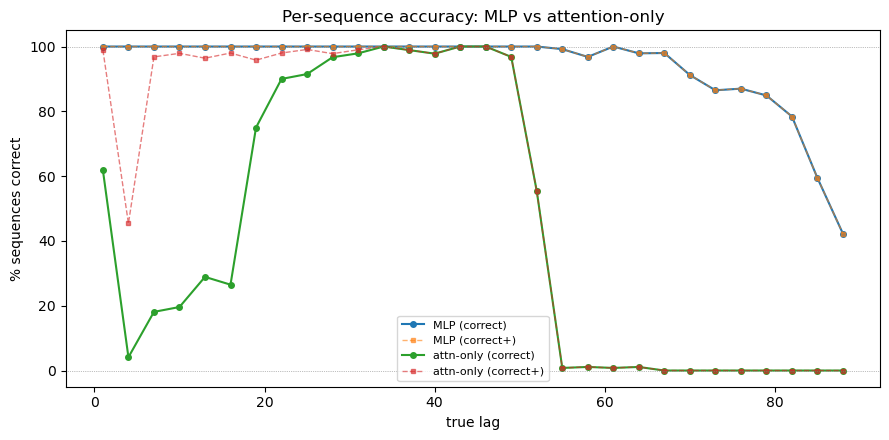

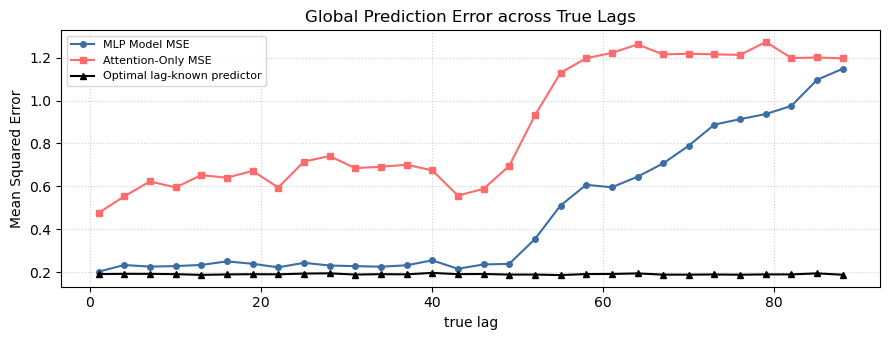

In [15]:
model = AutocorrRoPE(d_model=64, d_head=64, n_layers=4, n_heads=1, use_mlp=True).to(device)
model.load_state_dict(torch.load('models/sweep_d64_4L_mlp.pt', map_location=device))
torch.cuda.empty_cache()
far_lags = list(range(1, 90, 3))   # 50, 53, ..., 89
x_far, _, lags_far = make_dataset_lagset(3000, 200, 0.9, far_lags, seed=11)
x_far, lags_far = x_far.to(device), lags_far.to(device)

model_mlp = AutocorrRoPE(d_model=64, d_head=64, n_layers=4, n_heads=1, use_mlp=True).to(device)
#model_mlp.load_state_dict(torch.load('models/extended_wd_overnight_sweep/mlp_lag50_rho90_wd0.01.pt', map_location=device))
model_mlp=model
model_mlp.eval()

model_attn = AutocorrRoPE(d_model=64, d_head=64, n_layers=4, n_heads=1, use_mlp=False).to(device)
model_attn.load_state_dict(torch.load('models/attn_d64_4L_int_ext.pt', map_location=device))  # adjust name if needed
model_attn.eval()


def analyze(m):
    d = per_sequence_df(m, x_far, lags_far, device,
                        candidate_lags=range(1, 200),
                        min_peak_corr=0.1, tol=0, max_harmonic=3, batch_size=256)
    d['dist'] = d.best_k - d.true_lag
    return d

dfs = {'MLP': analyze(model_mlp), 'attn-only': analyze(model_attn)}
# a dict of dataframes. same as the standard one outputted by the per_sequence_df,
# but with another col representing how far the model's "chosen lag" was off from the true lag.

# Figure A: per-sequence accuracy curves, both models overlaid
plt.figure(figsize=(9, 4.5))
for name, d in dfs.items():
    s = summarize(d)
    plt.plot(s.index, s['pct_correct'], marker='o', ms=4, lw=1.5, label=f'{name} (correct)')
    plt.plot(s.index, s['pct_correct_plus'], marker='s', ms=3, lw=1, ls='--', alpha=0.6,
             label=f'{name} (correct+)')
plt.xlabel('true lag'); plt.ylabel('% sequences correct'); plt.ylim(-5, 105)
plt.axhline(0, color='gray', lw=0.5, ls=':'); plt.axhline(100, color='gray', lw=0.5, ls=':')
plt.legend(fontsize=8); plt.title('Per-sequence accuracy: MLP vs attention-only')
plt.tight_layout(); plt.show()


lags_to_show = [50, 65, 80, 90, 110, 150]

# Compute the mean MSE per true lag
mlp_mse_profile = compute_dataset_mse(model_mlp, x_far, lags_far)
attn_mse_profile = compute_dataset_mse(model_attn, x_far, lags_far)

def compute_oracle_mse(x, lags, rho=0.9, burn_in_extra=30):
    rows = []

    with torch.no_grad():
        for L in sorted(lags.unique().detach().cpu().numpy()):
            L = int(L)
            x_L = x[lags == L]

            target = x_L[:, L + burn_in_extra:]
            pred = rho * x_L[:, burn_in_extra:-L]

            mse = ((pred - target) ** 2).mean().item()
            rows.append((L, mse))

    return pd.Series(dict(rows)).sort_index()

oracle_mse_profile = compute_oracle_mse(x_far, lags_far, rho=0.9, burn_in_extra=30)
# Figure C: Global Mean Squared Error across all sequences
plt.figure(figsize=(9, 3.5))
plt.plot(mlp_mse_profile.index, mlp_mse_profile.values, marker='o', ms=4, color='#3a6ea5', lw=1.5, label='MLP Model MSE')
plt.plot(attn_mse_profile.index, attn_mse_profile.values, marker='s', ms=4, color='#ff6b6b', lw=1.5, label='Attention-Only MSE')
plt.plot(oracle_mse_profile.index, oracle_mse_profile.values, marker='^', ms=4, color='black', lw=1.5, label='Optimal lag-known predictor')

plt.xlabel('true lag')
plt.ylabel('Mean Squared Error')
plt.title('Global Prediction Error across True Lags')
plt.grid(True, ls=':', alpha=0.6)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()



- The per-sequence accuracy/correct lag correlation metric stays near perfect for the MLP beyond 50 (training upper limit)
- However its MSE does seem to spike after 50.
- It's possible that for these instances from 50-67, the model "selected" the right lag (correlated its prediction most with the right lagged value) but that correlation was weaker, and attenuated, and this attenuation grows as you go further out of distribution.
- To investigate I will check the magnitudes of the correlations the model uses for each lag

/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:

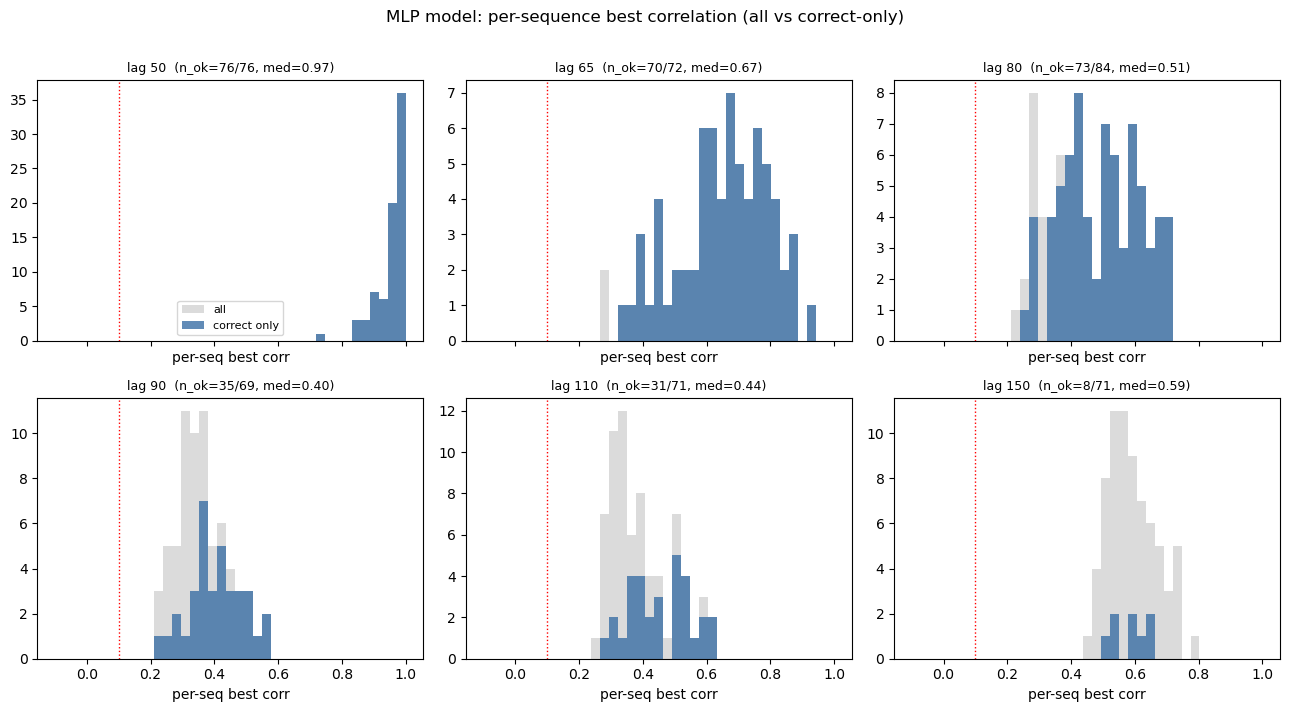

In [16]:
far_lags = list(range(5, 200, 5))   # 5,10,15,...195 — includes 50,65,80,90,110,150
x_far, _, lags_far = make_dataset_lagset(3000, 200, 0.9, far_lags, seed=11)
x_far, lags_far = x_far.to(device), lags_far.to(device)
dfs = {'MLP': analyze(model_mlp), 'attn-only': analyze(model_attn)}

lags_to_show = [50, 65, 80, 90, 110, 150]
d = dfs['MLP']

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
shared_bins = np.linspace(-0.1, 1.0, 40)

for ax, L in zip(axes.flatten(), lags_to_show):
    all_vals     = d[d.true_lag == L].best_c
    correct_vals = d[(d.true_lag == L) & (d.correct)].best_c

    ax.hist(all_vals,     bins=shared_bins, color='#cccccc', alpha=0.7, label='all')
    ax.hist(correct_vals, bins=shared_bins, color='#3a6ea5', alpha=0.8, label='correct only')
    ax.axvline(0.1, color='r', lw=1, ls=':')   # min_peak_corr threshold

    med = correct_vals.median() if len(correct_vals) else float('nan')
    ax.set_title(f'lag {L}  (n_ok={len(correct_vals)}/{len(all_vals)}, med={med:.2f})', fontsize=9)
    ax.set_xlabel('per-seq best corr')

axes.flatten()[0].legend(fontsize=8)
fig.suptitle('MLP model: per-sequence best correlation (all vs correct-only)', y=1.01)
fig.tight_layout()
plt.show()

- It seems like the magnitudes of the correlations do indeed weaken, in addition to becoming incorrect more often.
- Aligns with the view of the model's "confidence in the lag" decreasing with increased true lag. 

##### Other questions
- Would a different training process improve on the performance Out of Distribution? 
- Different architectual choices?

#### Beginning intepretability/probing
Questions:
- How does the model mechanistically recover a correlation, or a proxy for it?
- MLP contribution vs Attention 


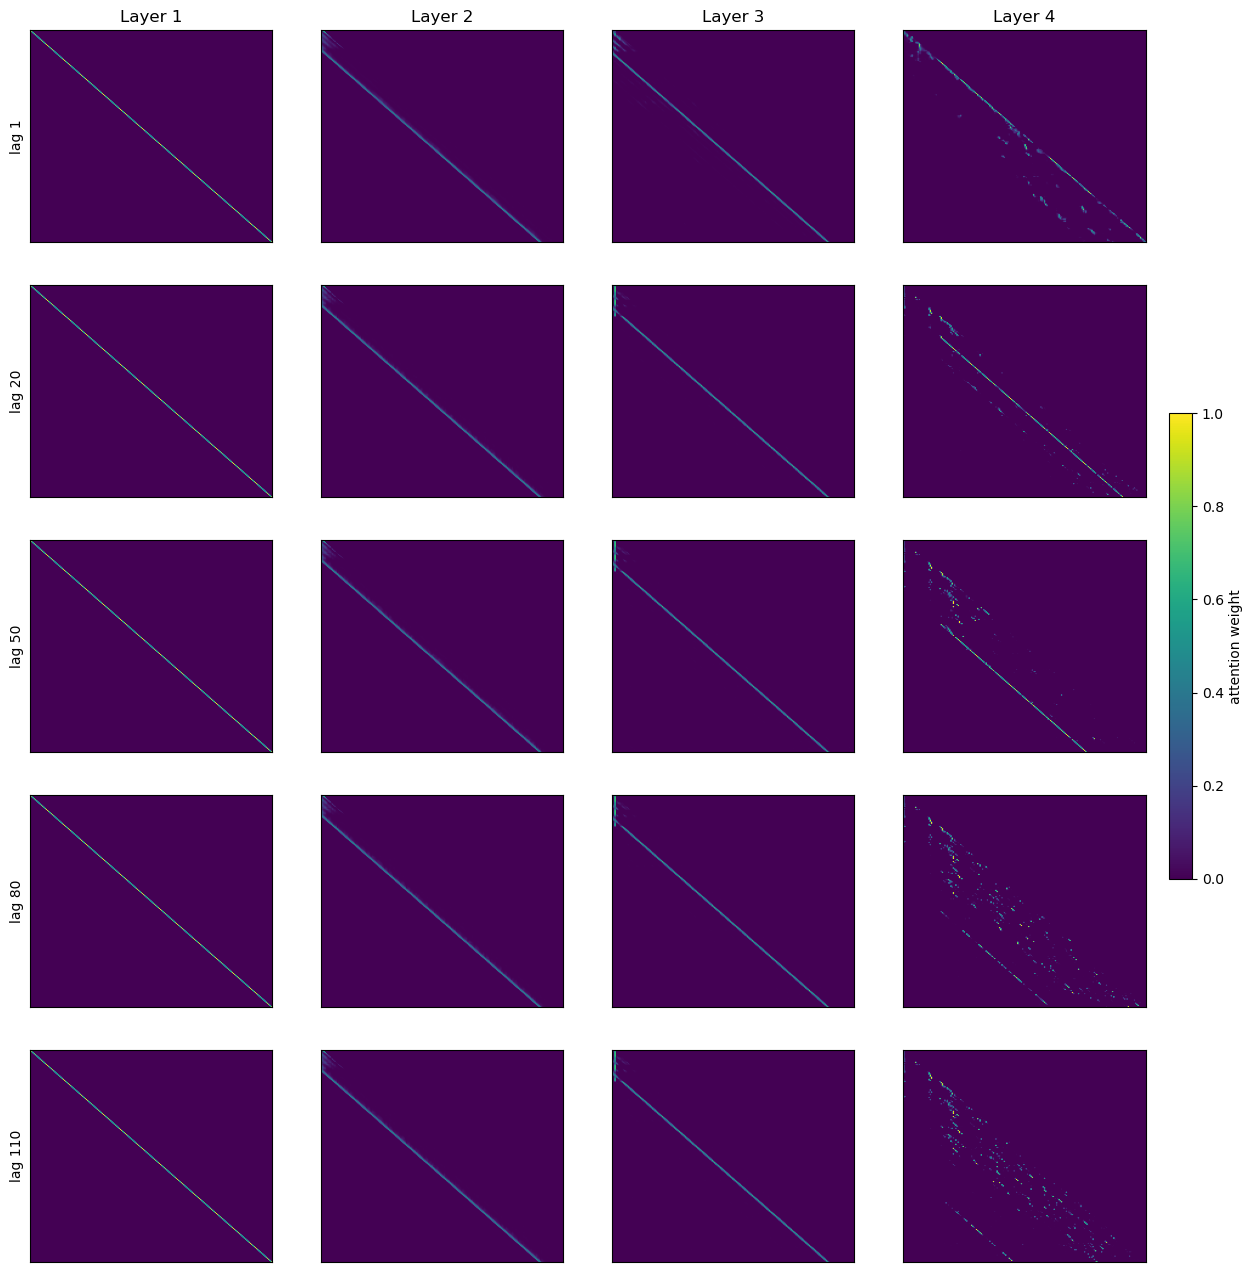

In [17]:
model = AutocorrRoPE(d_model=64, d_head=64, n_layers=4, n_heads=1, use_mlp=True).to(device)
model.load_state_dict(torch.load('models/sweep_d64_4L_mlp.pt', map_location=device))

model.eval()


LAGS_TO_SHOW = [1, 20, 50, 80, 110]
SEQ = 0 # just one index to take one sample sequence index from the batched Attention output

fig, axes = plt.subplots(len(LAGS_TO_SHOW), 4, figsize=(15, 3.2*len(LAGS_TO_SHOW)))

im = None
for row, L in enumerate(LAGS_TO_SHOW):
    xL, _, lagsL = make_dataset_lagset(8, 200, 0.9, [L], seed=0)
    _, attnL,_,_ = model(xL.to(device))
    for layer in range(4):
        A = attnL[layer][SEQ].detach().cpu().numpy()
        ax = axes[row, layer]
        im = ax.imshow(A, cmap='viridis', origin='upper', aspect='auto',
                       vmin=0, vmax=1)               
        if row == 0:
            ax.set_title(f'Layer {layer+1}')
        if layer == 0:
            ax.set_ylabel(f'lag {L}', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='attention weight')  # shared colorbar
plt.show()

- There doesn't seem to be much change between each of these matrices over lag
- However the layers do show their own distinct patterns (or lack thereof)
- I will try to quantify the strips in layers 1 2 and 3 using an offset profile.
    - The function will need to track the average amount of attention a query gives to a key that's "d" steps behind it, and test different offsets, d.
    - This will allow it to find the intercept of the line more precisely.

- Explanation of the function:
    - For every query position (i.e, 1-200, from the beginning to the end of our sequence):
        - For every valid offset 
        - Take an offset d, and identify the key position at query_position - d. 
            - an "offset" is simply denoting a query being ahead (in position) of the key it's attending to by a certain amount. Therefore, it would visually correspond to a diagonal strip of light on the graph
        - Repeat for each valid offset
    - This gives a query_pos x d array.
    - Then take the average of the values of the cells for each query_pos (avg over the rows)
        - (will also take std. deviation to analyze it)
    - This gives an array of average activation values in the A matrix for each offset. 

- I'll write the function then apply it to each layer, for a variety of lag values both in and out of training dist. 

In [18]:
A=attnL[layer-1][SEQ].detach().cpu().numpy()
def offset_profile(A, max_offset=150):
    T = A.shape[0]
    values_at_offset = [[] for _ in range(max_offset)]   
    # one list of attention activations per offset

    for query_pos in range(T):
        for d in range(0, min(query_pos + 1, max_offset)):
            # note: if query_pos = 0, and d is 1:
            # you'd think that would produce a negative key pos
            # but then we have for d in range(1,1), so the inner loop doesnt run
            key_pos = query_pos - d
            values_at_offset[d].append(A[query_pos, key_pos])

    # take the mean of each row/sublist. 
    avg_attention_at_offset = np.array([np.mean(v) for v in values_at_offset])
    # this is now [mean_at_offset_1, mean_at_offset_2... etc]
    # note: the resulting array is indexed by offset:
    # avg_attention_at_offset[d] = mean attention at distance d.

    # take the std of each row/sublist
    std_attention_at_offset = np.array([np.std(v) for v in values_at_offset])


    return avg_attention_at_offset, std_attention_at_offset
    

LAGS_TO_SHOW = [1,20,50,60,80,110,150]
print('CORRELATION = 0.9')
for L in LAGS_TO_SHOW:
    xL, _, lagsL = make_dataset_lagset(8, 200, 0.9, [L], seed=0)
    # make dataset with a single of the lags
    _, attnL,_,_ = model(xL.to(device))
    for layer in range(0,4):
        A = attnL[layer][SEQ].detach().cpu().numpy()
        prof = offset_profile(A) # [avgs], [stds]
        # offset_profile returns a list of means for each offset, indexed by offset
        # so the argmax = most concentrated d
        peak_offset = int(prof[0].argmax()) # taking the biggest avg'd offset over the query positions. (= the index)
        peak_value = prof[0][peak_offset] 
        std_offset = prof[1][peak_offset]
        print(f'lag={L:4d}  layer={layer+1}  peak_offset={peak_offset:4d}  peak_value={peak_value:.3f}, spread = {std_offset}')
    print('=======================================================================================')

print('\n\n\nCORRELATION = 1')
for row, L in enumerate(LAGS_TO_SHOW):
    xL, _, lagsL = make_dataset_lagset(8, 200, 1, [L], seed=0)
    _, attnL,_,_ = model(xL.to(device))
    for layer in range(0,4):
        A = attnL[layer][SEQ].detach().cpu().numpy()
        prof = offset_profile(A)
        # offset_profile returns a list of means for each offset, indexed by offset
        # so the argmax = most concentrated d
        peak_offset = int(prof[0].argmax())
        peak_value = prof[0][peak_offset]
        std_offset = prof[1][peak_offset]
        print(f'lag={L:4d}  layer={layer+1}  peak_offset={peak_offset:4d}  peak_value={peak_value:.3f}, spread = {std_offset}')
    print('=======================================================================================')
        

CORRELATION = 0.9
lag=   1  layer=1  peak_offset=   1  peak_value=0.991, spread = 0.0018515723058953881
lag=   1  layer=2  peak_offset=  20  peak_value=0.453, spread = 0.035743456333875656
lag=   1  layer=3  peak_offset=  22  peak_value=0.607, spread = 0.04625426232814789
lag=   1  layer=4  peak_offset=   0  peak_value=0.471, spread = 0.35334908962249756
lag=  20  layer=1  peak_offset=   1  peak_value=0.991, spread = 0.0013955032918602228
lag=  20  layer=2  peak_offset=  20  peak_value=0.470, spread = 0.017731353640556335
lag=  20  layer=3  peak_offset=  22  peak_value=0.616, spread = 0.07830473780632019
lag=  20  layer=4  peak_offset=  19  peak_value=0.700, spread = 0.37652117013931274
lag=  50  layer=1  peak_offset=   1  peak_value=0.991, spread = 0.0015303711406886578
lag=  50  layer=2  peak_offset=  20  peak_value=0.466, spread = 0.02909790351986885
lag=  50  layer=3  peak_offset=  22  peak_value=0.620, spread = 0.07669238746166229
lag=  50  layer=4  peak_offset=  49  peak_value=0.

- Layers 1-3 seem to have the exact same pattern all the time 
    - possibly scaffolding for later computations
- but layer 4, on the other hand, always has a peak offset that lines up with the correct lag.
    - This could be at least partially where the lag is encoded inside the model.
- but much higher spread.
- There does appear to be a distinct line on each of the layer 4 matrices
- Additionally, Layer 4's peak_value increases in rho=1
    - possibly coinciding with how "certain" the measurement is

Possibility: The fundamental mechanism for lag retrieval is still present in the model well out of distribution, but this attention signal dilutes the further you go out of dist.  

Questions:

    1) Does this line consolidate for query positions after the warmup period (i.e., when there's enough time to recognize the lag in question?)
    2) Does the attention-only model exhibit this same behavior?


This is pretty interesting. But before reading too far into it, I want to aggregate these results across multiple sequences, and see if they reappear:

In [19]:

def layer4_peak_vs_lag(model, lags, device, make_dataset_lagset,
                       n_seq=64, T=200, rho=0.9, layer=3, seed=0):
    """
    For each lag, run a BATCH of n_seq sequences, compute the offset-profile peak
    (offset + value) PER SEQUENCE, then report mean/std ACROSS sequences.
    Returns a list of dicts, one per lag.
    """
    model.eval()
    rows = []
    i=0
    for L in lags:
        xL, _, _ = make_dataset_lagset(n_seq, T, rho, [L], seed=seed+i)
        _, attnL, *_ = model(xL.to(device))
        A_all = attnL[layer].detach().cpu().numpy()   # (n_seq, T, T)

        peak_offsets, peak_values = [], []
        for s in range(A_all.shape[0]):
            mean, _ = offset_profile(A_all[s])
            po = int(mean.argmax())
            peak_offsets.append(po)
            peak_values.append(mean[po])

        peak_offsets = np.array(peak_offsets)
        peak_values  = np.array(peak_values)
        # fraction of sequences whose peak is at the correct stripe (L-1, within +/-1)
        frac_on_lag = np.mean(np.abs(peak_offsets - (L - 1)) <= 1)
        rows.append(dict(
            lag=L,
            peak_value_mean=float(peak_values.mean()),
            peak_value_std=float(peak_values.std()),
            peak_offset_median=int(np.median(peak_offsets)),
            frac_on_correct_stripe=float(frac_on_lag),
            n=int(A_all.shape[0]),
        ))
        i+=1
    return rows


def print_table(rows):
    print(f"{'lag':>4} {'peak_val(mean±std)':>22} {'med_offset':>11} {'%on_stripe':>11} {'n':>4}")
    for r in rows:
        print(f"{r['lag']:>4} "
              f"{r['peak_value_mean']:>10.3f} ± {r['peak_value_std']:<8.3f} "
              f"{r['peak_offset_median']:>11} "
              f"{r['frac_on_correct_stripe']*100:>10.0f}% "
              f"{r['n']:>4}")
rows = layer4_peak_vs_lag(model, [1,20,50,60,80,110,150], device,
                          make_dataset_lagset, n_seq=64, layer=3)  # layer=3 → 4th layer (0-idx)
print_table(rows)

 lag     peak_val(mean±std)  med_offset  %on_stripe    n
   1      0.403 ± 0.072              0        100%   64
  20      0.699 ± 0.065             19        100%   64
  50      0.728 ± 0.043             49        100%   64
  60      0.477 ± 0.086             59        100%   64
  80      0.302 ± 0.079             79        100%   64
 110      0.195 ± 0.053            109         97%   64
 150      0.092 ± 0.028             44         45%   64


Does the same hold true for attention?

In [20]:
LAGS_TO_SHOW = [1,20,50,60,80,110,150]
print('CORRELATION = 0.9')
for row, L in enumerate(LAGS_TO_SHOW):
    xL, _, lagsL = make_dataset_lagset(8, 200, 0.9, [L], seed=0)
    _, attnL,_,_ = model_attn(xL.to(device))
    for layer in range(0,4):
        A = attnL[layer][SEQ].detach().cpu().numpy()
        prof = offset_profile(A)
        # offset_profile returns a list of means for each offset, indexed by offset
        # so the argmax = most concentrated d
        peak_offset = int(prof[0].argmax())
        peak_value = prof[0][peak_offset]
        std_offset = prof[1][peak_offset]
        print(f'lag={L:4d}  layer={layer+1}  peak_offset={peak_offset:4d}  peak_value={peak_value:.3f}, spread = {std_offset}')
    print('=======================================================================================')

print('\n\n\nCORRELATION = 1')
for row, L in enumerate(LAGS_TO_SHOW):
    xL, _, lagsL = make_dataset_lagset(8, 200, 1, [L], seed=0)
    _, attnL,_,_ = model_attn(xL.to(device))
    for layer in range(0,4):
        A = attnL[layer][SEQ].detach().cpu().numpy()
        prof = offset_profile(A)
        # offset_profile returns a list of means for each offset, indexed by offset
        # so the argmax = most concentrated d
        peak_offset = int(prof[0].argmax())
        peak_value = prof[0][peak_offset]
        std_offset = prof[1][peak_offset]
        print(f'lag={L:4d}  layer={layer+1}  peak_offset={peak_offset:4d}  peak_value={peak_value:.3f}, spread = {std_offset}')
    print('=======================================================================================')
        

CORRELATION = 0.9
lag=   1  layer=1  peak_offset=   1  peak_value=0.937, spread = 0.07469027489423752
lag=   1  layer=2  peak_offset=  21  peak_value=0.279, spread = 0.0190003402531147
lag=   1  layer=3  peak_offset=  23  peak_value=0.557, spread = 0.17753493785858154
lag=   1  layer=4  peak_offset=   0  peak_value=0.229, spread = 0.30953454971313477
lag=  20  layer=1  peak_offset=   1  peak_value=0.945, spread = 0.0438479520380497
lag=  20  layer=2  peak_offset=  21  peak_value=0.283, spread = 0.015015724115073681
lag=  20  layer=3  peak_offset=  23  peak_value=0.659, spread = 0.08789172768592834
lag=  20  layer=4  peak_offset=  19  peak_value=0.187, spread = 0.2331767976284027
lag=  50  layer=1  peak_offset=   1  peak_value=0.947, spread = 0.05902630463242531
lag=  50  layer=2  peak_offset=  21  peak_value=0.281, spread = 0.015367984771728516
lag=  50  layer=3  peak_offset=  23  peak_value=0.640, spread = 0.0919000506401062
lag=  50  layer=4  peak_offset=  49  peak_value=0.213, sprea

- In the layer 4 attention matrix of the attn-only model, the pattern holds in distribution but collapses disastrously out of dist.


#### Activation patching of layer 4 attention 

- First will add new methods to the model that allow for modified forward pass


In [21]:
def _head_patched(self, xin, params, pos, mask, A_patched=None):
    WQ, WK, WV, WO = params
    if A_patched is not None:
        return A_patched, (A_patched @ (xin @ WV)) @ WO
    Q = self.apply_rope(xin @ WQ, pos)
    K = self.apply_rope(xin @ WK, pos)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_head)
    scores = scores.masked_fill(mask, float('-inf'))
    A = F.softmax(scores, dim=-1)
    return A, (A @ (xin @ WV)) @ WO 

def forward_L4_attention_ablated(self, r, A_4):
    B, T = r.shape
    pos = torch.arange(T, device=r.device).unsqueeze(0).expand(B, T)
    x = self.W_r(r.unsqueeze(-1))

    idx = torch.arange(T, device=r.device)
    mask = (idx.unsqueeze(0) > idx.unsqueeze(1))

    attns = [] 
    resids_post_attn = [] 
    resids_post_mlp = []
    for li, heads in enumerate(self.layers):
        delta = 0
        if li < 3:
            for head_params in heads:
                A, d = self._head(x, head_params, pos, mask)
                delta = delta + d
                attns.append(A)
        else: # on the forth layer:
            for head_params in heads:
                A, d = self._head(x, head_params, pos, mask, A_patched=A_4)
                delta = delta + d
                attns.append(A)
        x = x + delta
        resids_post_attn.append(x)        

        if self.use_mlp:
            x = x + self.mlps[li](x)
        resids_post_mlp.append(x) 

    pred = self.W_U(x).squeeze(-1)
    return pred, attns, resids_post_attn, resids_post_mlp

# attach methods to the model
import types
model._head = types.MethodType(_head_patched, model)
model.forward_L4_attention_ablated = types.MethodType(forward_L4_attention_ablated, model)



##### Also need a modified evaluator function to take in already-passed sequences, rather than a model that then predicts sequences in-function. 

In [22]:
def per_sequence_preds_df(pred_tensor, x_eval, lags_eval, candidate_lags,
                          start_offset=30, min_peak_corr=0.1, tol=0,
                          max_harmonic=3): 
    # we pass in the batch of sequences, their predictions, and corresp. lags
    """
    input: 
    
    pred_tensor: a tensor of model predicitons like (B,T) to evaluate.

    x_eval, when shifted 1 index ahead will provide the targets to evaluate against
    NOTE: this means per_sequence_preds_df is handling the index shifting INTERNALLY


    this function evaluates raw prediction tensors directly without running a model forward pass.
    Without the forward pass is needed because I need to modify the model in its prediction process.
    So I will patch the model and create its predictions for the sequences externally,
    then pass the model in here.
    """
    pred = pred_tensor.cpu() if torch.is_tensor(pred_tensor) else torch.tensor(pred_tensor)

    x_cpu, lags_cpu = x_eval.cpu(), lags_eval.cpu()
    T = x_cpu.shape[1]
    candidate_lags = list(candidate_lags)
    records = []

    for L in lags_cpu.unique().tolist():
        L = int(L)
        rows = torch.where(lags_cpu == L)[0]
        start = L + start_offset

        for i in rows.tolist():
            a = pred[i, start:].detach().numpy()
            ks, cs = [], []
            for k in candidate_lags:
                if start - k + 1 < 0:
                    continue
                b = x_cpu[i, start - k + 1: T - k + 1].detach().numpy() # index shift HERE (the +1)
                if b.shape != a.shape:
                    continue
                ks.append(k)
                cs.append(np.corrcoef(a, b)[0, 1])
            ks, cs = np.array(ks), np.array(cs)

            order = np.argsort(cs)[::-1]
            best_k, best_c = int(ks[order[0]]), float(cs[order[0]])
            runner_k = int(ks[order[1]]) if len(cs) > 1 else -1
            runner_c = float(cs[order[1]]) if len(cs) > 1 else np.nan

            cleared = best_c >= min_peak_corr
            correct = bool(cleared and abs(best_k - L) <= tol)
             # ditching correct_plus check for now to keep things simpler

            records.append(dict(
                true_lag=L, best_k=best_k, best_c=best_c,
                runner_k=runner_k, runner_c=runner_c,
                cleared=bool(cleared), correct=correct,
            ))

    return pd.DataFrame.from_records(records) # a df where each row = sequence's true lag, was it correct, and best_k

#### Patching with lag = 10 vs. lag = 40.
- will use 50 sequences of each lag. 
- 10 and 40 were chosen since they are well in-dist, but also far apart, with the hope of expressing any patched behavior with clarity

In [23]:

num_seqs= 50
T = 200

seqs_10 = np.array([generate_autocorr(T, rho=0.9, lag=10, seed=i) for i in range(num_seqs)])
# above is numpy (50,200)

x_10_batch = torch.tensor(seqs_10, dtype=torch.float32).to(device) # torch tensor (50,200)

seqs_40 = np.array([generate_autocorr(T, rho=0.9, lag=40, seed=i) for i in range(num_seqs)])
# above is numpy (50,200)
x_40_batch = torch.tensor(seqs_40, dtype=torch.float32).to(device) # torch tensor (50,200)

### First running normal forward passes through each lag as a control, and to get the aggregated As

pred10, attns10, _, _ = model(x_10_batch)
pred40, attns40, _, _ = model(x_40_batch)

A_10_L4_batch = attns10[3] # (50, 200, 200)

A_40_L4_batch = attns40[3] # (50, 200, 200)

# aggregating all the attention patterns element-wise
A_10_mean = A_10_L4_batch.mean(dim=0,keepdim=True) #(1,200,200)
A_40_mean = A_40_L4_batch.mean(dim=0, keepdim=True) #(1,200,200)

patched_10_40_pred, _,_,_ = model.forward_L4_attention_ablated(r=x_10_batch, A_4 = A_40_mean)
patched_40_10_pred, _,_,_ = model.forward_L4_attention_ablated(r=x_40_batch, A_4 = A_10_mean)
#(50,200) both.

#### Now running the patching

In [24]:
candidate_lags = range(1, 200)

# Dictionary to hold the dataframes for all combinations
patching_results = {}

# =====================================================================
# CONDITION 1: Clean Baseline (Lag 10 sequences, Unpatched Model)
# Expectation: High tracking accuracy at k=10
# =====================================================================
patching_results['clean_lag10'] = per_sequence_preds_df(
    pred_tensor=pred10,
    x_eval=x_10_batch,
    lags_eval=torch.tensor([10] * 50),  # True data lag is 10
    candidate_lags=candidate_lags,
    start_offset=30,
    min_peak_corr=0.1,
    tol=0
)

# =====================================================================
# CONDITION 2: Clean Baseline (Lag 40 sequences, Unpatched Model)
# Expectation: High tracking accuracy at k=40
# =====================================================================
patching_results['clean_lag40'] = per_sequence_preds_df(
    pred_tensor=pred40,
    x_eval=x_40_batch,
    lags_eval=torch.tensor([40] * 50),  # True data lag is 40
    candidate_lags=candidate_lags,
    start_offset=30,
    min_peak_corr=0.1,
    tol=0
)

# =====================================================================
# CONDITION 3: Patched 10-with-40 (Lag 10 data, Forced to look via L4_mean_40)
# Expectation: Circuit Hijack. If L4 controls lookback, best_k will jump 
# to 40, meaning it will fail the true_lag=10 evaluation (correct=False).
# =====================================================================
patching_results['patched_10_with_40'] = per_sequence_preds_df(
    pred_tensor=patched_10_40_pred,
    x_eval=x_10_batch,
    lags_eval=torch.tensor([10] * 50),  # Data tokens are still physically lag 10
    candidate_lags=candidate_lags,
    start_offset=30,
    min_peak_corr=0.1,
    tol=0
)

# =====================================================================
# CONDITION 4: Patched 40-with-10 (Lag 40 data, Forced to look via L4_mean_10)
# Expectation: Circuit Hijack. If L4 controls lookback, best_k will drop 
# to 10, failing the true_lag=40 evaluation (correct=False).
# =====================================================================
patching_results['patched_40_with_10'] = per_sequence_preds_df(
    pred_tensor=patched_40_10_pred,
    x_eval=x_40_batch,
    lags_eval=torch.tensor([40] * 50),  # Data tokens are still physically lag 40
    candidate_lags=candidate_lags,
    start_offset=30,
    min_peak_corr=0.1,
    tol=0
)

# =====================================================================
# Control Batches: Diagnostic Baseline Summary
# =====================================================================
control_names = ['clean_lag10', 'clean_lag40']

print(f"{'Control Condition':<25} | {'Pct Correct (tol=0)':<20} | {'Mean Corr (Correct Only)':<25}")
print("-" * 78)

for name in control_names:
    df = patching_results[name]
    
    # Calculate % of sequences that hit tol=0 exactly
    pct_correct = df['correct'].mean() * 100
    
    # Isolate only the correct sequences to get the pure tracking correlation
    correct_sequences = df[df['correct']]
    if len(correct_sequences) > 0:
        mean_c_correct = correct_sequences['best_c'].mean()
    else:
        mean_c_correct = float('nan') # Handle cases where a baseline cliff occurs
        
    print(f"{name:<25} | {pct_correct:<19.1f}% | {mean_c_correct:<25.4f}")

# =====================================================================
# Patched Batches: Counterfactual Hijack Summary
# =====================================================================
patched_conditions = {
    'patched_10_with_40': {'target_lag': 40},
    'patched_40_with_10': {'target_lag': 10}
}

# =====================================================================
# Top-K Distribution Breakdown for All Conditions
# =====================================================================
print("--- BEST_K DISTRIBUTION BREAKDOWN ---")

for name, df in patching_results.items():
    print(f"\nCondition: {name}")
    print("-" * 40)
    
    top_counts = df['best_k'].value_counts().head(3)
    # top_counts is a Series: index = k_value, value = count, sorted descending
    
    total = len(df)
    for rank, (k_val, count) in enumerate(top_counts.items(), start=1):
        pct = count / total * 100
        print(f"  Rank {rank}: lag k = {int(k_val):<3} | Chosen by {pct:>5.1f}% of seqs (n={count})")

Control Condition         | Pct Correct (tol=0)  | Mean Corr (Correct Only) 
------------------------------------------------------------------------------
clean_lag10               | 100.0              % | 0.9696                   
clean_lag40               | 100.0              % | 0.9643                   
--- BEST_K DISTRIBUTION BREAKDOWN ---

Condition: clean_lag10
----------------------------------------
  Rank 1: lag k = 10  | Chosen by 100.0% of seqs (n=50)

Condition: clean_lag40
----------------------------------------
  Rank 1: lag k = 40  | Chosen by 100.0% of seqs (n=50)

Condition: patched_10_with_40
----------------------------------------
  Rank 1: lag k = 40  | Chosen by 100.0% of seqs (n=50)

Condition: patched_40_with_10
----------------------------------------
  Rank 1: lag k = 10  | Chosen by 100.0% of seqs (n=50)


In [25]:
# NOTE: per_sequence_preds_df handles index-shifting internally for the correlation metric.
# Here (MSE) we shift manually AND mask the burn-in (positions before lag+burn_in,
# where no prediction is possible) so the cross-condition comparison is apples-to-apples.
import torch.nn.functional as F

def masked_mse(pred, target, L, burn_in=30):
    """pred, target: (B, T). Align pred[t]->target[t+1], then drop positions
    before L+burn_in where the lag isn't yet available."""
    pred_s   = pred[:, :-1]      # pred[t] for t=0..T-2  (predicts x[t+1])
    target_s = target[:, 1:]     # x[t+1]
    start = L + burn_in          # first position where lag L is avail able + burn-in
    if start >= pred_s.shape[1]:
        return float('nan')
    return F.mse_loss(pred_s[:, start:], target_s[:, start:]).item()

mse_results = [
    {
        "Condition": "clean_lag10",
        "Expected Target Lag %": f"{(patching_results['clean_lag10']['best_k'] == 10).mean()*100:.1f}%",
        "MSE vs. True Data":      f"{masked_mse(pred10, x_10_batch, 10):.6f}",
        "MSE vs. Counterfactual": f"{masked_mse(pred10, x_40_batch, 10):.6f}",
    },
    {
        "Condition": "clean_lag40",
        "Expected Target Lag %": f"{(patching_results['clean_lag40']['best_k'] == 40).mean()*100:.1f}%",
        "MSE vs. True Data":      f"{masked_mse(pred40, x_40_batch, 40):.6f}",
        "MSE vs. Counterfactual": f"{masked_mse(pred40, x_10_batch, 40):.6f}",
    },
    {
        "Condition": "patched_10_with_40", 
        "Expected Target Lag %": f"{(patching_results['patched_10_with_40']['best_k'] == 40).mean()*100:.1f}%",
        "MSE vs. True Data":      f"{masked_mse(patched_10_40_pred, x_10_batch, 10):.6f}",
        "MSE vs. Counterfactual": f"{masked_mse(patched_10_40_pred, x_40_batch, 10):.6f}",
    },
    {
        "Condition": "patched_40_with_10",
        "Expected Target Lag %": f"{(patching_results['patched_40_with_10']['best_k'] == 10).mean()*100:.1f}%",
        "MSE vs. True Data":      f"{masked_mse(patched_40_10_pred, x_40_batch, 40):.6f}",
        "MSE vs. Counterfactual": f"{masked_mse(patched_40_10_pred, x_10_batch, 40):.6f}",
    },
]

summary_df = pd.DataFrame(mse_results)
print("=" * 95)
print(f"{'Condition':<22} | {'Expected Target Lag %':<18} | {'MSE vs. True Data':<22} | {'MSE vs. Counterfactual':<22}")
print("=" * 95)
for _, r in summary_df.iterrows():
    print(f"{r['Condition']:<22} | {r['Expected Target Lag %']:<18} | {r['MSE vs. True Data']:<22} | {r['MSE vs. Counterfactual']:<22}")
print("=" * 95)

Condition              | Expected Target Lag % | MSE vs. True Data      | MSE vs. Counterfactual
clean_lag10            | 100.0%             | 0.229386               | 1.145680              
clean_lag40            | 100.0%             | 0.246101               | 1.215394              
patched_10_with_40     | 100.0%             | 0.631729               | 0.948744              
patched_40_with_10     | 100.0%             | 1.530252               | 0.785579              


##### Notes on the activation patching of Layer 4 results

- Swapping the activations between lag 40 and lag 10 passes for the attention matrix of layer 4 appears to successfuly hijack the model's prediction mode, from basing its prediction off of one lag to basing it off of another.
    - Note: the patches used the Aggregated attention matrices for each respective lag - the goal was to isolate the lag specific structure by aggregating this way, ruling out imperfections/idiosyncracies in individual sequences. (like taking the "average lag 10 attention matrix" for that layer)
- The patches show success in terms of both the custom sequence-level correlation metric, and loss (MSE). 
    - The "chosen" lag (the offset from the prediction that results in the highest correlation with the lagged counterpart) completely flips to correspond with the lag that the patched matrix came from. 
- One thing to note however is that the MSE from patching the lag 10 sequences with the lag 40 matrix, the resulting MSE, while higher than the non-patched counterparts, is still relatively close to them. 
    - This could actually make sense thinking about the structure of our generating process though. 
    - Thinking about it: for a sequence where lag=L, s[t] is correlated with s[t-L]. 
    - By extension, it can also be shown that s[t] is also correlated to with s[t-kL], (k is integer) to a milder degree with increasing k
    - Thus, if the model looks back 40 sequences instead of 10, it is still capturing some of the fundamental correlation in the generation process, but to a lesser extent. 
    - However note if the lag is 40, that means s[t] is correlated with s[t-40], but fractional multiples of L are not correlated with L. This could explain the asymmetry between the degree of worsening of the loss between the patched runs.

- To solidify these results I will also run a patching experiment where the attention matrices are not aggregated, i.e. one sequence's pass takes one attention matrix from the other lag's pass:

In [26]:
# =====================================================================
# PER-SEQUENCE (non-aggregated) patching: each recipient gets ONE
# specific donor matrix, not the mean. Pass full (50,T,T) instead of mean.
# =====================================================================

patched_10_40_single, *_ = model.forward_L4_attention_ablated(r=x_10_batch, A_4=A_40_L4_batch)
patched_40_10_single, *_ = model.forward_L4_attention_ablated(r=x_40_batch, A_4=A_10_L4_batch)

# permuted control: recipient i <- a RANDOM lag-donor (not its own index).
# if hijack still holds, it's the shared lag-structure, not donor-recipient alignment.
perm = torch.randperm(50)
patched_10_40_perm, *_ = model.forward_L4_attention_ablated(r=x_10_batch, A_4=A_40_L4_batch[perm])
patched_40_10_perm, *_ = model.forward_L4_attention_ablated(r=x_40_batch, A_4=A_10_L4_batch[perm])

# ---- evaluate all four with the same readout ----
single_results = {}
for name, pred, x_eval, true_lag in [
    ('single_10_with_40', patched_10_40_single, x_10_batch, 10),
    ('single_40_with_10', patched_40_10_single, x_40_batch, 40),
    ('perm_10_with_40',   patched_10_40_perm,   x_10_batch, 10),
    ('perm_40_with_10',   patched_40_10_perm,   x_40_batch, 40),
]:
    single_results[name] = per_sequence_preds_df(
        pred_tensor=pred,
        x_eval=x_eval,
        lags_eval=torch.tensor([true_lag] * 50),
        candidate_lags=range(1, 200),
        start_offset=30, min_peak_corr=0.1, tol=0,
    )

# ---- report the best_k each condition lands on ----
print(f"{'Condition':<22} | {'top best_k':<12} | {'% choosing it':<14} | {'mean best_c':<10}")
print("-" * 70)
for name, df in single_results.items():
    top_k = df['best_k'].mode().iloc[0]
    pct   = (df['best_k'] == top_k).mean() * 100
    mean_c = df['best_c'].mean()
    print(f"{name:<22} | {int(top_k):<12} | {pct:<13.1f}% |    {mean_c:<10.4f}")

Condition              | top best_k   | % choosing it  | mean best_c
----------------------------------------------------------------------
single_10_with_40      | 40           | 100.0        % |    0.8098    
single_40_with_10      | 10           | 100.0        % |    0.9007    
perm_10_with_40        | 40           | 100.0        % |    0.8137    
perm_40_with_10        | 10           | 100.0        % |    0.8893    


#### Pre-programming the attention matrix to confirm the offset is indeed the measure of lag in the model

- I will now manually code attention matrices to have certain offsets in order to confirm that the corresponding "stripe" deterministically influences the model's most highly ranked lag.
- The plan is to vertically shift a diagonal line, starting after the warmup + burn in period, across many offsets to create an attention matrix for each lag.
    - Then, I will vary the matrix to see which lag it encodes for a variety of lag values (using our corr metric and by comparing MSE)

In [27]:
def create_stripe_attention(lag, T=200, burn_in=30):
    A = np.zeros((T, T))
    offset = lag-1
    for query_t in range(offset  + burn_in, T):
        #NOTE: recall if lag equaled L, the stripe sat with offset L-1 between q and k
        # hence the +1
        key_t = query_t - offset
        A[query_t, key_t] = 1.0
    return torch.tensor(A, dtype=torch.float32).unsqueeze(0)  # (1, T, T)

lags_to_test = [3, 7, 11, 13, 19, 29, 40,67]

print(f"{'Synthetic lag':<15} | {'top best_k':<12} | {'% chose it':<12} | {'mean best_c':<10}")
print("-" * 60)

for lag in lags_to_test:
    A_synthetic = create_stripe_attention(lag, T=200).to(device)

    # patch into lag-10 data (true lag is 10, but we're forcing attention to look at `lag`)
    pred_syn, *_ = model.forward_L4_attention_ablated(r=x_10_batch, A_4=A_synthetic)

    df_syn = per_sequence_preds_df(
        pred_tensor=pred_syn,
        x_eval=x_10_batch,
        lags_eval=torch.tensor([10] * 50),
        candidate_lags=range(1, 200),
        start_offset=30, min_peak_corr=0.1, tol=0,
    )

    top_k   = int(df_syn['best_k'].mode().iloc[0])
    pct     = (df_syn['best_k'] == top_k).mean() * 100
    mean_c  = df_syn['best_c'].mean()
    print(f"{lag:<15} | {top_k:<12} | {pct:<11.1f}% | {mean_c:<10.4f}")





Synthetic lag   | top best_k   | % chose it   | mean best_c
------------------------------------------------------------
3               | 3            | 100.0      % | 0.9981    
7               | 7            | 100.0      % | 0.9985    
11              | 11           | 100.0      % | 0.9990    
13              | 13           | 100.0      % | 0.9905    
19              | 19           | 100.0      % | 0.9697    
29              | 29           | 100.0      % | 0.9341    
40              | 40           | 100.0      % | 0.8948    
67              | 37           | 100.0      % | 0.5539    


- for all true synthetic lags (except 67), the programmed offset corresponded to the true lag.
- To reconcile this result with model's prediction performance, I will also do the following sequence:
    1) generate a sequence with true lag = 40 (from the previous cell)
    2) for every lag within a large range (5-90), patch the attention matrix in L4. with a programmed one corresponding to that lag value (so offset = lag-1), and plot the resulting MSE

- I'd expect to see a sharp dip at 40, and then a smaller dip at 80.

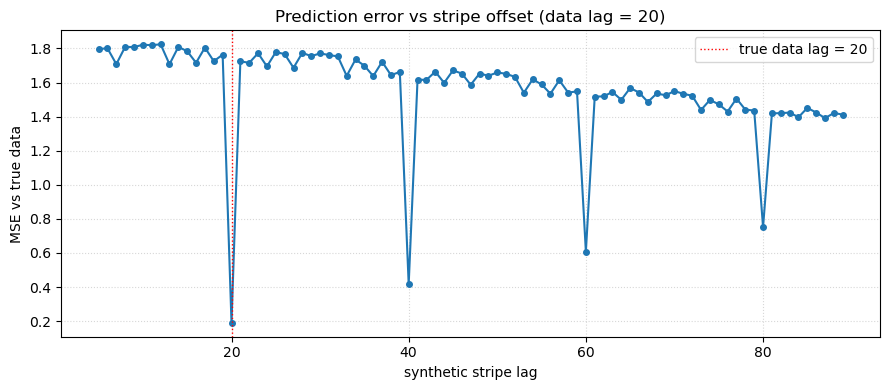

In [28]:
test_lag = 20
seqs_test = np.array([generate_autocorr(T, rho=0.9, lag=test_lag, seed=i) for i in range(num_seqs)])
x_test = torch.tensor(seqs_test, dtype=torch.float32).to(device) # torch tensor (50,200)
target = x_test        # its own data is the target (masked_mse handles the shift)

stripe_lags = list(range(5, 90, 1))   # sweep synthetic lags around 40
mses = []

for slag in stripe_lags:
    A_syn = create_stripe_attention(slag, T=200).to(device)
    pred_syn, *_ = model.forward_L4_attention_ablated(r=x_test, A_4=A_syn)
    # mask burn-in by the DATA's true lag 
    m = masked_mse(pred_syn, x_test, test_lag)
    mses.append(m)

plt.figure(figsize=(9, 4))
plt.plot(stripe_lags, mses, marker='o', ms=4)
plt.axvline(test_lag, color='r', ls=':', lw=1, label=f'true data lag = {test_lag}')
plt.xlabel('synthetic stripe lag'); plt.ylabel('MSE vs true data')
plt.title(f'Prediction error vs stripe offset (data lag = {test_lag})')
plt.legend(); plt.grid(True, ls=':', alpha=0.5); plt.tight_layout(); plt.show()


Question:
- Does the lag get represented anywhere before the layer 4 attention?
- Will probe the residual stream activations to address

#### Creating the Probe Dataset

running: layer=1  post_mlp=False
layer=1  post_mlp=False  R²=-0.012  shuffle=-0.005±0.003
running: layer=1  post_mlp=True
layer=1  post_mlp=True  R²=-0.023  shuffle=-0.018±0.008
running: layer=2  post_mlp=False
layer=2  post_mlp=False  R²=-0.029  shuffle=-0.022±0.005
running: layer=2  post_mlp=True
layer=2  post_mlp=True  R²=-0.026  shuffle=-0.046±0.013
running: layer=3  post_mlp=False
layer=3  post_mlp=False  R²=-0.039  shuffle=-0.055±0.018
running: layer=3  post_mlp=True
layer=3  post_mlp=True  R²=0.031  shuffle=-0.062±0.007
running: layer=4  post_mlp=False
layer=4  post_mlp=False  R²=0.043  shuffle=-0.063±0.013
running: layer=4  post_mlp=True
layer=4  post_mlp=True  R²=-0.028  shuffle=-0.071±0.012


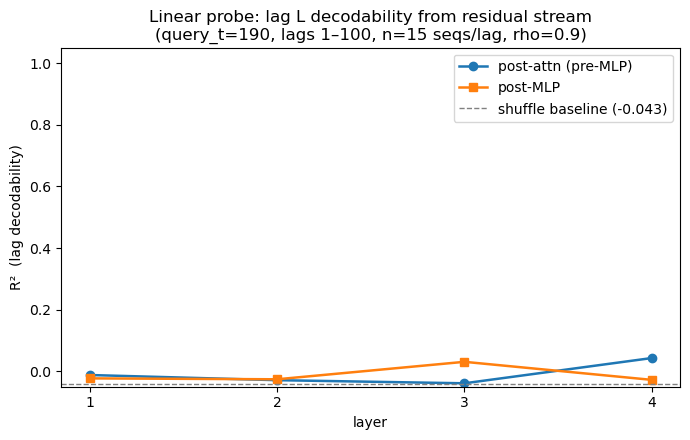

In [29]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

def run_lag_probe_full(model, layer, post_mlp, query_t=200, n_per_lag=30, alpha=1.0, n_shuffles=5,
    lag_range = (1,100),rho=0.9):
    X,y = [],[]
    for lag in range(lag_range[0],lag_range[1]+1):
        for _ in range(n_per_lag):
            seq = generate_autocorr(T=200, rho=rho, lag=lag, seed=None)   # (T,) numpy
            x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)  # (1, T)
            with torch.no_grad():
                pred, attns, resids_post_attn, resids_post_mlp = model(x)
            resid = resids_post_attn[layer-1] if not post_mlp else resids_post_mlp[layer-1]
            vec = resid[:, query_t, :].detach().cpu().numpy()   # (1, 64)
            X.append(vec)
            y.append(lag)
    
    X = np.vstack(X)
    y = np.array(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    probe = Ridge(alpha=alpha)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)   # <-- defined FIRST

    r2 = cross_val_score(probe, X_scaled, y, cv=cv, scoring='r2').mean()   # <-- uses cv

    shuffle_r2s = []
    for _ in range(n_shuffles):
        y_shuf = np.random.permutation(y)
        shuffle_r2s.append(cross_val_score(probe, X_scaled, y_shuf, cv=cv, scoring='r2').mean())   # <-- also cv

    shuffle_mean = np.mean(shuffle_r2s)
    shuffle_std  = np.std(shuffle_r2s)
    print(f'layer={layer}  post_mlp={post_mlp}  R²={r2:.3f}  '
        f'shuffle={shuffle_mean:.3f}±{shuffle_std:.3f}')
    return r2, shuffle_mean, shuffle_std


results = {}
for layer in range(1, 5):
    for post_mlp in [False, True]:
        print(f'running: layer={layer}  post_mlp={post_mlp}')
        r2, sh_mean, sh_std = run_lag_probe_full(
            model, layer=layer, post_mlp=post_mlp,
            query_t=199, n_per_lag=15, lag_range=(1, 100), rho=0.9
        )
        results[(layer, post_mlp)] = (r2, sh_mean, sh_std)

# ---- plot ----
layers = list(range(1, 5))
r2_pre_mlp  = [results[(l, False)][0] for l in layers]
r2_post_mlp = [results[(l, True)][0]  for l in layers]

# shuffle baseline: average the means across all runs (should be ~constant, near 0)
sh_means = [results[(l, pm)][1] for l in layers for pm in [False, True]]
shuffle_floor = np.mean(sh_means)

plt.figure(figsize=(7, 4.5))
plt.plot(layers, r2_pre_mlp,  marker='o', lw=1.8, label='post-attn (pre-MLP)')
plt.plot(layers, r2_post_mlp, marker='s', lw=1.8, label='post-MLP')
plt.axhline(shuffle_floor, color='gray', ls='--', lw=1,
            label=f'shuffle baseline ({shuffle_floor:.3f})')
plt.xlabel('layer')
plt.ylabel('R²  (lag decodability)')
plt.title('Linear probe: lag L decodability from residual stream\n'
          f'(query_t=190, lags 1–100, n={15} seqs/lag, rho=0.9)')
plt.ylim(-0.05, 1.05)
plt.xticks(layers)
plt.legend()
plt.tight_layout()
plt.show()



- Probing the resid. stream vectors after each layer gives no signal.
- This is interesting since the attention of layer 4 seemed to capture lag.

Possibilities:
1) The model could be using the residual stream to represent something else other than lag; e.g., computations that downstream, produce the next predicted value.
    - i.e. "lag" *relationship* lives in the attention and/or MLP but never in the resid. stream vecs themselves.
2) There could be a nonlinear representation in the residual stream - provided by the MLPs.

Question:
- All vectors start as scaled multiples of each other. How does this change throughout the model?


In [30]:
import torch.nn.functional as F
seq = generate_autocorr(T=200, rho=0.9, lag=80, seed=0)
x=torch.tensor(seq,dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    pred, attns, resids_post_attn, resids_post_mlp = model(x)

query_t=199
prev=None

prev = None
for li in range(4):
    after_attn = resids_post_attn[li][0, query_t, :]
    after_mlp  = resids_post_mlp[li][0, query_t, :]

    delta = after_mlp - after_attn               # the MLP's contribution vector
    mlp_delta   = delta.norm().item()            # how big the MLP's move is
    stream_norm = after_mlp.norm().item()        # size of the full post-MLP stream
    ratio = mlp_delta / stream_norm              # move size relative to stream


    cos = F.cosine_similarity(delta, after_attn, dim=0).item()

    print(f'layer {li+1}: ||MLP delta||={mlp_delta:6.3f}  ||stream||={stream_norm:6.3f}  '
          f'ratio={ratio:.3f}  cos(delta,stream)={cos:+.3f}')

    if prev is not None:
        layer_delta = (after_mlp - prev).norm().item()
        print(f'         ||full layer {li+1} change||={layer_delta:.3f}  rel={layer_delta/stream_norm:.3f}')
    prev = after_mlp

layer 1: ||MLP delta||=11.996  ||stream||=14.344  ratio=0.836  cos(delta,stream)=+0.220
layer 2: ||MLP delta||= 9.258  ||stream||=16.699  ratio=0.554  cos(delta,stream)=-0.238
         ||full layer 2 change||=10.756  rel=0.644
layer 3: ||MLP delta||=12.059  ||stream||=21.416  ratio=0.563  cos(delta,stream)=-0.309
         ||full layer 3 change||=13.772  rel=0.643
layer 4: ||MLP delta||=14.922  ||stream||=14.388  ratio=1.037  cos(delta,stream)=-0.787
         ||full layer 4 change||=12.491  rel=0.868


- The magnitude and cosine similarity change significantly, even in early layers (where the attention pattern is stagnant)
- The MLP also seems to have a very large effect
- in layer 4 especially there is a lot of cancelling going on ... the cosine sim is negative and the ratio is relatively high.

#### Question:
- One hypthesis is that after Attention in layer 4, each vector is most similar to its lagged counterpart.


In [31]:
print(model.W_r.bias)

Parameter containing:
tensor([ 0.2677,  0.0515, -0.2408, -0.0957,  0.2071,  0.3041,  0.0421, -0.1764,
        -0.3353, -0.1481, -0.0195,  0.0669, -0.0696,  0.1145, -0.0074,  0.2860,
         0.2000,  0.0762, -0.0040, -0.0476,  0.1313,  0.0813,  0.2149, -0.0059,
        -0.0102,  0.2983, -0.1225,  0.2004, -0.2638,  0.1411,  0.3196,  0.2021,
        -0.0209, -0.0005,  0.2510,  0.0105,  0.2135,  0.0711, -0.1241, -0.3322,
        -0.0046, -0.2658, -0.0529, -0.2960,  0.1649,  0.0229,  0.0678, -0.2956,
         0.0351,  0.0066,  0.1384, -0.0015, -0.0007, -0.2662, -0.1731, -0.2613,
         0.0104, -0.0472, -0.1218,  0.4332, -0.0735, -0.0384,  0.0093,  0.2088],
       requires_grad=True)


#### Analyzing models' performance metrics in comparison to one another.

analyzing 2L MLP
analyzing 3L MLP
analyzing 4L MLP
analyzing 5L MLP


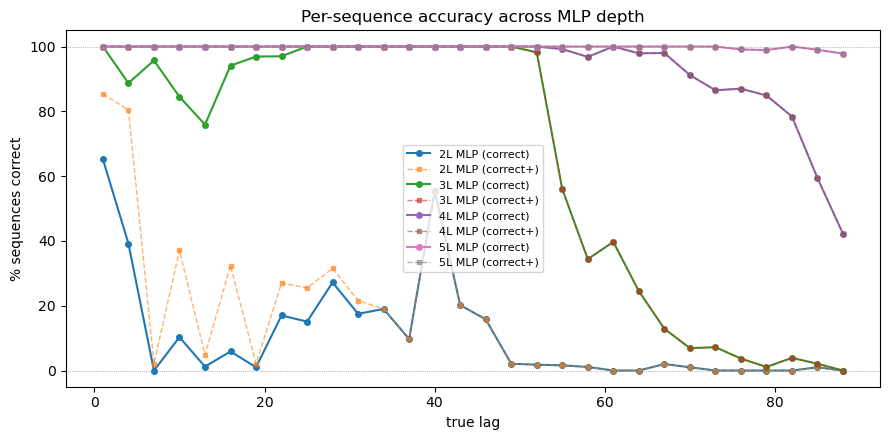

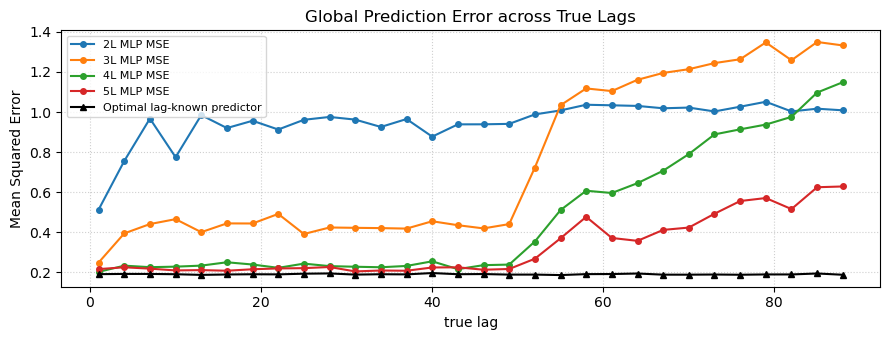

In [32]:
far_lags = list(range(1, 90, 3))
x_far, _, lags_far = make_dataset_lagset(3000, 200, 0.9, far_lags, seed=11)
x_far, lags_far = x_far.to(device), lags_far.to(device)

model_specs = [
    ("2L MLP", "models/sweep_d64_2L_mlp.pt", 2),
    ("3L MLP", "models/sweep_d64_3L_mlp.pt", 3),
    ("4L MLP", "models/sweep_d64_4L_mlp.pt", 4),
    ("5L MLP", "models/sweep_d64_5L_mlp.pt", 5),
]

def load_depth_model(path, n_layers):
    m = AutocorrRoPE(d_model=64, d_head=64, n_layers=n_layers, n_heads=1, use_mlp=True).to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m

def analyze(m):
    d = per_sequence_df(m, x_far, lags_far, device,
                        candidate_lags=range(1, 200),
                        min_peak_corr=0.1, tol=0, max_harmonic=3, batch_size=256)
    d['dist'] = d.best_k - d.true_lag
    return d

dfs = {}
mse_profiles = {}

for name, path, n_layers in model_specs:
    print(f"analyzing {name}")

    model_tmp = load_depth_model(path, n_layers)

    dfs[name] = analyze(model_tmp)
    mse_profiles[name] = compute_dataset_mse(model_tmp, x_far, lags_far)

    del model_tmp
    torch.cuda.empty_cache()


# Figure A: per-sequence accuracy curves, all MLP models overlaid
plt.figure(figsize=(9, 4.5))
for name, d in dfs.items():
    s = summarize(d)
    plt.plot(s.index, s['pct_correct'], marker='o', ms=4, lw=1.5, label=f'{name} (correct)')
    plt.plot(s.index, s['pct_correct_plus'], marker='s', ms=3, lw=1, ls='--', alpha=0.6,
             label=f'{name} (correct+)')
plt.xlabel('true lag'); plt.ylabel('% sequences correct'); plt.ylim(-5, 105)
plt.axhline(0, color='gray', lw=0.5, ls=':'); plt.axhline(100, color='gray', lw=0.5, ls=':')
plt.legend(fontsize=8); plt.title('Per-sequence accuracy across MLP depth')
plt.tight_layout(); plt.show()


lags_to_show = [50, 65, 80, 90, 110, 150]

def compute_oracle_mse(x, lags, rho=0.9, burn_in_extra=30):
    rows = []

    with torch.no_grad():
        for L in sorted(lags.unique().detach().cpu().numpy()):
            L = int(L)
            x_L = x[lags == L]

            target = x_L[:, L + burn_in_extra:]
            pred = rho * x_L[:, burn_in_extra:-L]

            mse = ((pred - target) ** 2).mean().item()
            rows.append((L, mse))

    return pd.Series(dict(rows)).sort_index()

oracle_mse_profile = compute_oracle_mse(x_far, lags_far, rho=0.9, burn_in_extra=30)


# Figure C: Global Mean Squared Error across all sequences
plt.figure(figsize=(9, 3.5))

for name, mse_profile in mse_profiles.items():
    plt.plot(mse_profile.index, mse_profile.values, marker='o', ms=4, lw=1.5, label=f'{name} MSE')

plt.plot(oracle_mse_profile.index, oracle_mse_profile.values, marker='^', ms=4, color='black', lw=1.5, label='Optimal lag-known predictor')

plt.xlabel('true lag')
plt.ylabel('Mean Squared Error')
plt.title('Global Prediction Error across True Lags')
plt.grid(True, ls=':', alpha=0.6)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [33]:

model_2L = AutocorrRoPE(d_model=64, d_head=64, n_layers=2, n_heads=1, use_mlp=True).to(device)
model_2L.load_state_dict(torch.load('models/sweep_d64_2L_mlp.pt', map_location=device))
model_2L.eval()

model_3L = AutocorrRoPE(d_model=64, d_head=64, n_layers=3, n_heads=1, use_mlp=True).to(device)
model_3L.load_state_dict(torch.load('models/sweep_d64_3L_mlp.pt', map_location=device))
model_3L.eval()

model_5L = AutocorrRoPE(d_model=64, d_head=64, n_layers=5, n_heads=1, use_mlp=True).to(device)
model_5L.load_state_dict(torch.load('models/sweep_d64_5L_mlp.pt', map_location=device))
model_5L.eval()

print("loaded 2L / 3L / 5L")
SEQ = 0
LAGS_TO_SHOW = [1, 20, 50, 60, 80, 110, 150]

models_to_check = {
    '2L': model_2L,
    '3L': model_3L,
    '4L': model,
    '5L': model_5L,
}

for model_name, mdl in models_to_check.items():
    n = mdl.n_layers
    print(f"\n{'='*70}")
    print(f"MODEL: {model_name}  ({n} layers)")
    print(f"{'='*70}")
    for L in LAGS_TO_SHOW:
        xL, _, _ = make_dataset_lagset(8, 200, 0.9, [L], seed=0)
        with torch.no_grad():
            _, attnL, _, _ = mdl(xL.to(device))
        for layer in range(n):
            A = attnL[layer][SEQ].detach().cpu().numpy()
            prof = offset_profile(A)
            peak_offset = int(np.nanargmax(prof[0]))
            peak_value  = prof[0][peak_offset]
            std_offset  = prof[1][peak_offset]
            print(f"  [{model_name}] lag={L:4d}  layer={layer+1}  "
                  f"peak_offset={peak_offset:4d}  "
                  f"peak_value={peak_value:.3f}  "
                  f"spread={std_offset:.3f}")
        print()

loaded 2L / 3L / 5L

MODEL: 2L  (2 layers)
  [2L] lag=   1  layer=1  peak_offset=   3  peak_value=0.092  spread=0.042
  [2L] lag=   1  layer=2  peak_offset=  28  peak_value=0.035  spread=0.012

  [2L] lag=  20  layer=1  peak_offset=   3  peak_value=0.092  spread=0.042
  [2L] lag=  20  layer=2  peak_offset=  22  peak_value=0.045  spread=0.016

  [2L] lag=  50  layer=1  peak_offset=   3  peak_value=0.091  spread=0.042
  [2L] lag=  50  layer=2  peak_offset=  22  peak_value=0.043  spread=0.017

  [2L] lag=  60  layer=1  peak_offset=   3  peak_value=0.091  spread=0.042
  [2L] lag=  60  layer=2  peak_offset=  22  peak_value=0.043  spread=0.017

  [2L] lag=  80  layer=1  peak_offset=   3  peak_value=0.091  spread=0.041
  [2L] lag=  80  layer=2  peak_offset=  22  peak_value=0.043  spread=0.017

  [2L] lag= 110  layer=1  peak_offset=   3  peak_value=0.091  spread=0.042
  [2L] lag= 110  layer=2  peak_offset=  22  peak_value=0.045  spread=0.017

  [2L] lag= 150  layer=1  peak_offset=   3  peak_va

##### Before applying the patching method to these models, first I will create a more generalized patching forward method (as opposed to the current one, which is hardcoded to patch layer 4 attention specifically)

In [34]:
def _head_patched(self, xin, params, pos, mask, A_patched=None):
    WQ, WK, WV, WO = params
    if A_patched is not None:
        return A_patched, (A_patched @ (xin @ WV)) @ WO
    Q = self.apply_rope(xin @ WQ, pos)
    K = self.apply_rope(xin @ WK, pos)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_head)
    scores = scores.masked_fill(mask, float('-inf'))
    A = F.softmax(scores, dim=-1)
    return A, (A @ (xin @ WV)) @ WO 

def forward_attention_ablated(self, r, A_patch, patch_li): 
    """patches one attention matrix"""
    #can patch with the identity matrix if ablating
    B, T = r.shape
    pos = torch.arange(T, device=r.device).unsqueeze(0).expand(B, T)
    x = self.W_r(r.unsqueeze(-1))

    idx = torch.arange(T, device=r.device)
    mask = (idx.unsqueeze(0) > idx.unsqueeze(1))

    attns = [] 
    resids_post_attn = [] 
    resids_post_mlp = []
    for li, heads in enumerate(self.layers):
        delta = 0
        if li != patch_li:
            for head_params in heads:
                A, d = self._head(x, head_params, pos, mask)
                delta = delta + d
                attns.append(A)
        else: # on the forth layer:
            for head_params in heads:
                A, d = self._head(x, head_params, pos, mask, A_patched=A_patch)
                delta = delta + d
                attns.append(A)
        x = x + delta
        resids_post_attn.append(x)        

        if self.use_mlp:
            x = x + self.mlps[li](x)
        resids_post_mlp.append(x) 

    pred = self.W_U(x).squeeze(-1)
    return pred, attns, resids_post_attn, resids_post_mlp

# attach methods to the model
model._head = types.MethodType(_head_patched, model)
model.forward_L4_attention_ablated = types.MethodType(forward_L4_attention_ablated, model)



#### Now running the patching

In [35]:
import types

# attach generalized patching to all models
for mdl in [model, model_2L, model_3L, model_5L, model_attn]:
    mdl._head = types.MethodType(_head_patched, mdl)
    mdl.forward_attention_ablated = types.MethodType(forward_attention_ablated, mdl)

# ── data ──────────────────────────────────────────────────────
num_seqs = 50
T        = 200

seqs_10 = np.array([generate_autocorr(T, rho=0.9, lag=10, seed=i) for i in range(num_seqs)])
seqs_40 = np.array([generate_autocorr(T, rho=0.9, lag=40, seed=i) for i in range(num_seqs)])
x_10_batch = torch.tensor(seqs_10, dtype=torch.float32).to(device)
x_40_batch = torch.tensor(seqs_40, dtype=torch.float32).to(device)

# ── sweep ─────────────────────────────────────────────────────
models_to_patch = {
    '2L': model_2L,
    '3L': model_3L,
    '4L': model,
    '5L': model_5L,
}

for model_name, mdl in models_to_patch.items():
    final_li = mdl.n_layers - 1

    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}  (patching layer {final_li+1})")
    print(f"{'='*60}")

    # clean forward passes
    with torch.no_grad():
        pred10, attns10, _, _ = mdl(x_10_batch)
        pred40, attns40, _, _ = mdl(x_40_batch)

    A_10_mean = attns10[final_li].mean(dim=0, keepdim=True)
    A_40_mean = attns40[final_li].mean(dim=0, keepdim=True)

    # patched forward passes
    with torch.no_grad():
        patched_10_40, *_ = mdl.forward_attention_ablated(x_10_batch, A_40_mean, patch_li=final_li)
        patched_40_10, *_ = mdl.forward_attention_ablated(x_40_batch, A_10_mean, patch_li=final_li)

    # evaluate all four conditions
    conditions = [
        ('clean_lag10',        pred10,        x_10_batch, 10),
        ('clean_lag40',        pred40,        x_40_batch, 40),
        ('patched_10_with_40', patched_10_40, x_10_batch, 10),
        ('patched_40_with_10', patched_40_10, x_40_batch, 40),
    ]

    for cond_name, pred, x_eval, true_lag in conditions:
        df = per_sequence_preds_df(
            pred_tensor=pred,
            x_eval=x_eval,
            lags_eval=torch.tensor([true_lag] * num_seqs),
            candidate_lags=range(1, 200),
            start_offset=30, min_peak_corr=0.1, tol=0,
        )
        top_counts = df['best_k'].value_counts().head(3)
        total = len(df)
        print(f"\n  {cond_name}")
        for rank, (k_val, count) in enumerate(top_counts.items(), start=1):
            pct = count / total * 100
            print(f"    Rank {rank}: k={int(k_val):<3} | {pct:>5.1f}% (n={count})")


MODEL: 2L  (patching layer 2)

  clean_lag10
    Rank 1: k=40  |  66.0% (n=33)
    Rank 2: k=20  |  20.0% (n=10)
    Rank 3: k=10  |  10.0% (n=5)

  clean_lag40
    Rank 1: k=40  |  44.0% (n=22)
    Rank 2: k=21  |  12.0% (n=6)
    Rank 3: k=5   |   8.0% (n=4)

  patched_10_with_40
    Rank 1: k=40  |  70.0% (n=35)
    Rank 2: k=20  |  22.0% (n=11)
    Rank 3: k=10  |   6.0% (n=3)

  patched_40_with_10
    Rank 1: k=40  |  32.0% (n=16)
    Rank 2: k=21  |  18.0% (n=9)
    Rank 3: k=5   |  14.0% (n=7)

MODEL: 3L  (patching layer 3)

  clean_lag10
    Rank 1: k=10  |  70.0% (n=35)
    Rank 2: k=20  |  24.0% (n=12)
    Rank 3: k=30  |   6.0% (n=3)

  clean_lag40
    Rank 1: k=40  | 100.0% (n=50)

  patched_10_with_40
    Rank 1: k=40  | 100.0% (n=50)

  patched_40_with_10
    Rank 1: k=10  | 100.0% (n=50)

MODEL: 4L  (patching layer 4)

  clean_lag10
    Rank 1: k=10  | 100.0% (n=50)

  clean_lag40
    Rank 1: k=40  | 100.0% (n=50)

  patched_10_with_40
    Rank 1: k=40  | 100.0% (n=50)


In [36]:
# ── per-sequence (non-aggregated) + permuted control, all depths ──

for model_name, mdl in models_to_patch.items():
    final_li = mdl.n_layers - 1

    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}  — single-matrix + permuted patching")
    print(f"{'='*60}")

    with torch.no_grad():
        pred10, attns10, _, _ = mdl(x_10_batch)# pass thru model
        pred40, attns40, _, _ = mdl(x_40_batch)# pass thru model

    A_10_batch = attns10[final_li]   # (50, T, T) — one matrix per sequence
    A_40_batch = attns40[final_li]

    perm = torch.randperm(num_seqs)

    with torch.no_grad():
        # matched: recipient i gets donor i's own matrix
        single_10_40, *_ = mdl.forward_attention_ablated(x_10_batch, A_40_batch,patch_li=final_li)
        single_40_10, *_ = mdl.forward_attention_ablated(x_40_batch, A_10_batch,patch_li=final_li)
        # permuted: recipient i gets a random donor's matrix
        perm_10_40,   *_ = mdl.forward_attention_ablated(x_10_batch, A_40_batch[perm],patch_li=final_li)
        perm_40_10,   *_ = mdl.forward_attention_ablated(x_40_batch, A_10_batch[perm],patch_li=final_li)

    conditions = [
        ('single_10_with_40', single_10_40, x_10_batch, 10),
        ('single_40_with_10', single_40_10, x_40_batch, 40),
        ('perm_10_with_40',   perm_10_40,   x_10_batch, 10),
        ('perm_40_with_10',   perm_40_10,   x_40_batch, 40),
    ]

    print(f"\n  {'Condition':<22} | {'top k':<6} | {'%':>6} | {'mean_c':>7}")
    print(f"  {'-'*50}")
    for cond_name, pred, x_eval, true_lag in conditions:
        df = per_sequence_preds_df(
            pred_tensor=pred,
            x_eval=x_eval,
            lags_eval=torch.tensor([true_lag] * num_seqs),
            candidate_lags=range(1, 200),
            start_offset=30, min_peak_corr=0.1, tol=0,
        )
        top_k  = int(df['best_k'].mode().iloc[0])
        pct    = (df['best_k'] == top_k).mean() * 100
        mean_c = df['best_c'].mean()
        print(f"  {cond_name:<22} | {top_k:<6} | {pct:>5.1f}% | {mean_c:>7.4f}")


MODEL: 2L  — single-matrix + permuted patching

  Condition              | top k  |      % |  mean_c
  --------------------------------------------------
  single_10_with_40      | 40     |  62.0% |  0.5488
  single_40_with_10      | 40     |  38.0% |  0.3993
  perm_10_with_40        | 40     |  66.0% |  0.5485
  perm_40_with_10        | 40     |  34.0% |  0.3978

MODEL: 3L  — single-matrix + permuted patching

  Condition              | top k  |      % |  mean_c
  --------------------------------------------------
  single_10_with_40      | 40     | 100.0% |  0.7251
  single_40_with_10      | 10     |  96.0% |  0.5930
  perm_10_with_40        | 40     | 100.0% |  0.7251
  perm_40_with_10        | 10     |  94.0% |  0.5982

MODEL: 4L  — single-matrix + permuted patching

  Condition              | top k  |      % |  mean_c
  --------------------------------------------------
  single_10_with_40      | 40     | 100.0% |  0.8098
  single_40_with_10      | 10     | 100.0% |  0.9007
  per

#### Creating a new experiment to directly link patching to MSE
- The experiment will work like this:
Given a model, for a large number of iterations, do the following:
1) Generate a sequence with lag L.
2) For variety of lags, program the model's "stripe" in the final layer attention matrix to another lag, M. 
3) For each step where L % M != 0, record the MSE, and whether or not L=M.
- The aim is to repeat this and produce a dataset like:
|MSE|L==M|



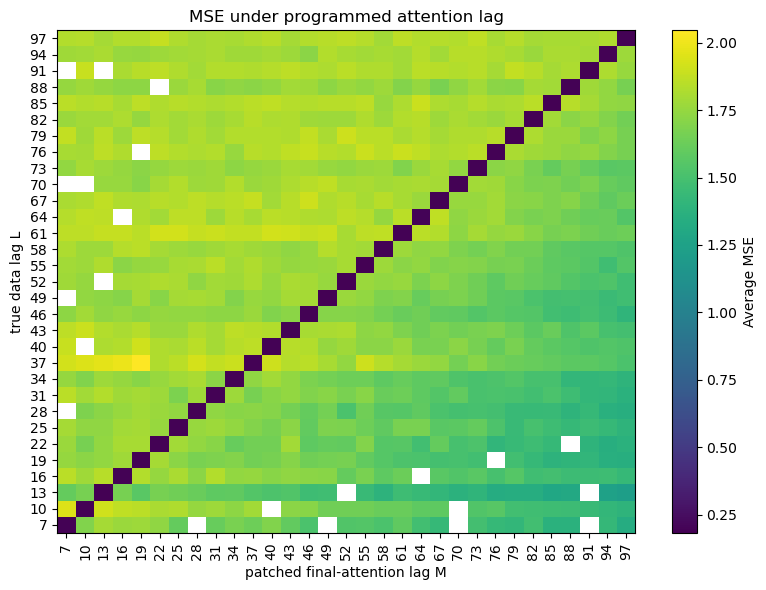

Diagonal L=M mean MSE: 0.19072405301755474
Off-diagonal non-multiple mean MSE: 1.7114475725788114
Diagonal median MSE: 0.19024727493524551
Off-diagonal median MSE: 1.6790470480918884
Known-lag floor: 0.18999999999999995


,mean,median,std,min,max,count
stripe_aligns_bool,,,,,,
False,1.711448,1.679047,0.428020,0.493486,5.887818,45400
True,0.190724,0.190247,0.025944,0.104664,0.315899,1550


In [37]:


def patch_sweep_experiment(model,lags_to_patch,lags_to_sweep, layer_to_patch, num_iterations=50, T=200, rho=0.9, burn_in=30):
    model.eval()
    records = []
    with torch.no_grad():
        for it in range(num_iterations):
            for L in lags_to_sweep:
                x_in = torch.tensor(generate_autocorr(200, 0.9, lag=L, seed=None),dtype=torch.float32,device=device).unsqueeze(0)
                for M in lags_to_patch: 
                    if L != M and ((L % M == 0) or (M % L == 0)):
                        continue
                    create_stripe_attention(lag = M, T= 200)
                    A_patch = create_stripe_attention(lag=M,T=T,burn_in=burn_in).to(device)
                    pred = model.forward_attention_ablated(x_in,A_patch,patch_li=layer_to_patch)
                    if isinstance(pred, tuple):
                        pred = pred[0]
                    target = x_in[:, 1:]
                    pred_clip = pred[:, :-1]
                    start = L + burn_in # note we are determing also by the Stripe's capability

                    mse = ((pred_clip[:, start:] - target[:, start:]) ** 2).mean().item()
                    records.append({
                        "iteration": it,
                        "true_lag": L,
                        "patched_lag": M,
                        "layer": layer_to_patch,
                        "stripe_aligns_bool": L == M,
                        "mse": mse,
                    })
        model.train()
        df = pd.DataFrame(records)
        mse_grid = df.pivot_table(index="true_lag", columns = "patched_lag",values="mse",aggfunc="mean")
        """ this mse_grid is now like:
         patched_lag      7      10     13
        true_lag
        7              0.22   1.34   1.41
        10             1.12   0.20   1.08
        13             1.43   1.21   0.23
        
         where each cell is a mean for that patched_lag/true_lag combination"""

        return df, mse_grid
    
lags_to_sweep = list(range(7,100,3))
lags_to_patch = list(range(7,100,3))
patch_df, patch_grid = patch_sweep_experiment(
    model=model,
    lags_to_patch=lags_to_patch,
    lags_to_sweep=lags_to_sweep,
    layer_to_patch=3,      # final layer for 4L model
    num_iterations=50,
    T=200,
    rho=0.9,
    burn_in=30
)
plt.figure(figsize=(8, 6))

plt.imshow(patch_grid.values, aspect="auto", origin="lower")

plt.colorbar(label="Average MSE")
plt.xticks(range(len(patch_grid.columns)), patch_grid.columns, rotation=90)
plt.yticks(range(len(patch_grid.index)), patch_grid.index)

plt.xlabel("patched final-attention lag M")
plt.ylabel("true data lag L")
plt.title("MSE under programmed attention lag")

plt.tight_layout()
plt.show()

diag = patch_df[patch_df["stripe_aligns_bool"]]
offdiag = patch_df[~patch_df["stripe_aligns_bool"]]

print("Diagonal L=M mean MSE:", diag["mse"].mean())
print("Off-diagonal non-multiple mean MSE:", offdiag["mse"].mean())
print("Diagonal median MSE:", diag["mse"].median())
print("Off-diagonal median MSE:", offdiag["mse"].median())
print("Known-lag floor:", 1 - 0.9**2)

display(
    patch_df
    .groupby("stripe_aligns_bool")["mse"]
    .agg(["mean", "median", "std", "min", "max", "count"])
)

##### Results
- When final layer attention is forced to attend to lag M, MSE is near-ideal only when M = L, excluding harmonic cases (where the true lag is a multiple of M, causing a minor correlation to occur between x[t-M] and x[t-L]). This suggests the final attention causally functions as lag-specific retrieval, and it seems to be robust out of distribution.
- Now i'll also try this experiment on the other models.

computing MSE: MLP 4L
computing MSE: attn 4L
computing MSE: attn 6L
computing MSE: attn 7L


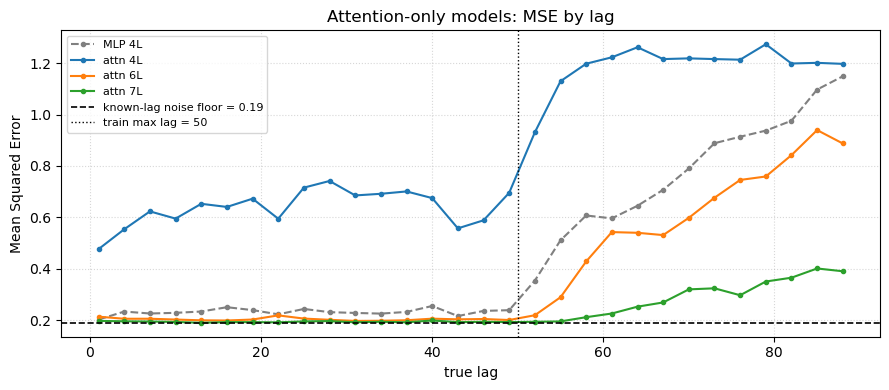


=== Average prediction correlation on eval lags ===
MLP 4L  : corr 0.803
attn 4L : corr 0.395
attn 6L : corr 0.867
attn 7L : corr 0.971


In [38]:

torch.cuda.empty_cache()

T, rho = 200, 0.9
far_lags = list(range(1, 90, 3))

x_far, _, lags_far = make_dataset_lagset(3000, T, rho, far_lags, seed=11)
x_far, lags_far = x_far.to(device), lags_far.to(device)


model_mlp_4L = AutocorrRoPE(
    d_model=64, d_head=64, n_layers=4, n_heads=1, use_mlp=True
).to(device)
model_mlp_4L.load_state_dict(torch.load('models/sweep_d64_4L_mlp.pt', map_location=device))
model_mlp_4L.eval()


model_attn_4L = AutocorrRoPE(
    d_model=64, d_head=64, n_layers=4, n_heads=1, use_mlp=False
).to(device)
model_attn_4L.load_state_dict(torch.load('models/attn_d64_4L_int_ext.pt', map_location=device))
model_attn_4L.eval()


model_attn_6L = AutocorrRoPE(
    d_model=64, d_head=64, n_layers=6, n_heads=1, use_mlp=False
).to(device)
model_attn_6L.load_state_dict(torch.load('models/sweep_d64_6L_attn_lag1_50_extended.pt', map_location=device))
model_attn_6L.eval()


model_attn_7L = AutocorrRoPE(
    d_model=64, d_head=64, n_layers=7, n_heads=1, use_mlp=False
).to(device)
model_attn_7L.load_state_dict(torch.load('models/sweep_d64_7L_attn_lag1_50_extended.pt', map_location=device))
model_attn_7L.eval()


models = {
    'MLP 4L': model_mlp_4L,
    'attn 4L': model_attn_4L,
    'attn 6L': model_attn_6L,
    'attn 7L': model_attn_7L,
}

mse_profiles = {}

for name, mdl in models.items():
    print("computing MSE:", name)
    mse_profiles[name] = compute_dataset_mse(mdl,x_far,lags_far,start_offset=30)


plt.figure(figsize=(9, 4))

for name, profile in mse_profiles.items():
    if name == 'MLP 4L':
        plt.plot(profile.index,profile.values,marker='o',ms=3,lw=1.5,ls='--',color='gray',
            label=name
        )
    else:
        plt.plot(profile.index,profile.values,marker='o',ms=3,lw=1.5,
            label=name
        )

plt.axhline(1 - rho**2, color='black', lw=1.2, ls='--',
            label='known-lag noise floor = 0.19')
plt.axvline(50, color='black', lw=1, ls=':',
            label='train max lag = 50')

plt.xlabel('true lag')
plt.ylabel('Mean Squared Error')
plt.title('Attention-only models: MSE by lag')
plt.grid(True, ls=':', alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()



m = lambda d: float(np.mean(list(d.values())))

print("\n=== Average prediction correlation on eval lags ===")
for name, mdl in models.items():
    corr = m(correlation_by_lag(mdl, x_far, lags_far, device, verbose=False))
    print(f"{name:8s}: corr {corr:.3f}")

- This reinforces the trend common with the MLP models:
    - adding layers seems to reduce loss, and the "slant" flattens the more you add.
    - None replicate the optimal estimating that occurs In-distribution perpetually as you go further OOD.


## Attention distributions in the 7-layer attention-only model

For each programmed lag, generate many independent sequences and compute each layer's attention mass as a function of query-key offset. Because the model predicts $x_{t+1}$ from position $t$, a data lag $L$ corresponds to a final-layer retrieval offset $D=L-1$. The plots use the ordinary linear attention scale; the shaded region is the 5th–95th percentile across sequences.

running lag 10...


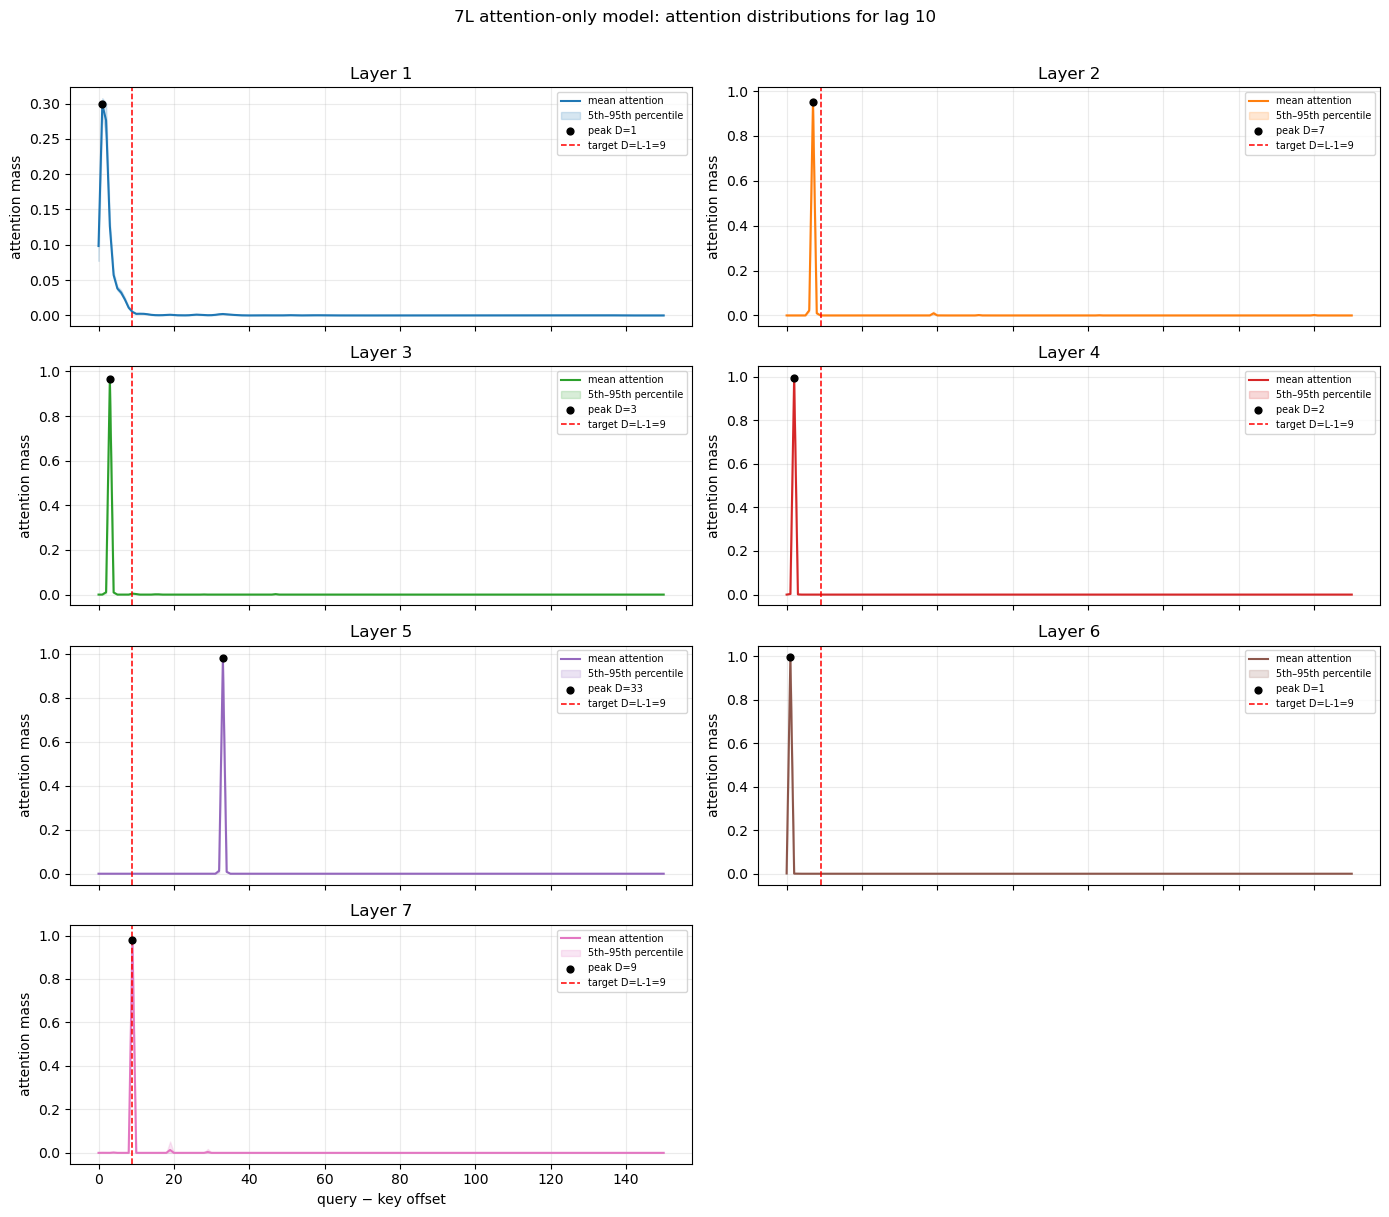

running lag 20...


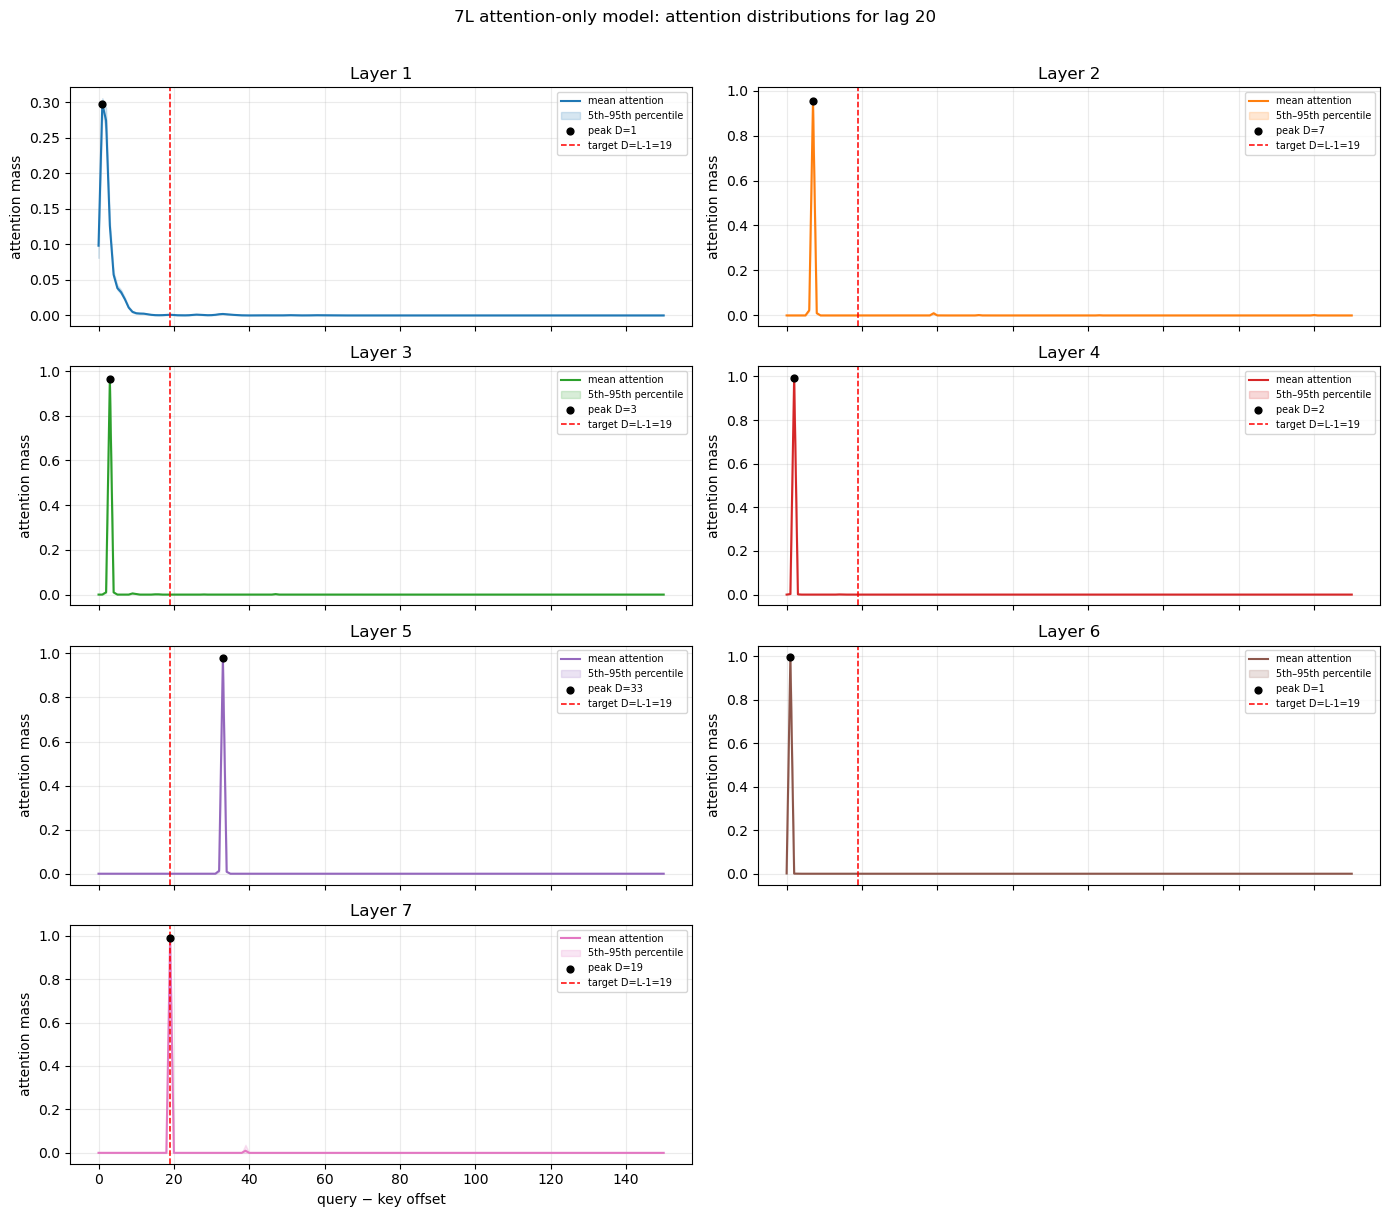

running lag 40...


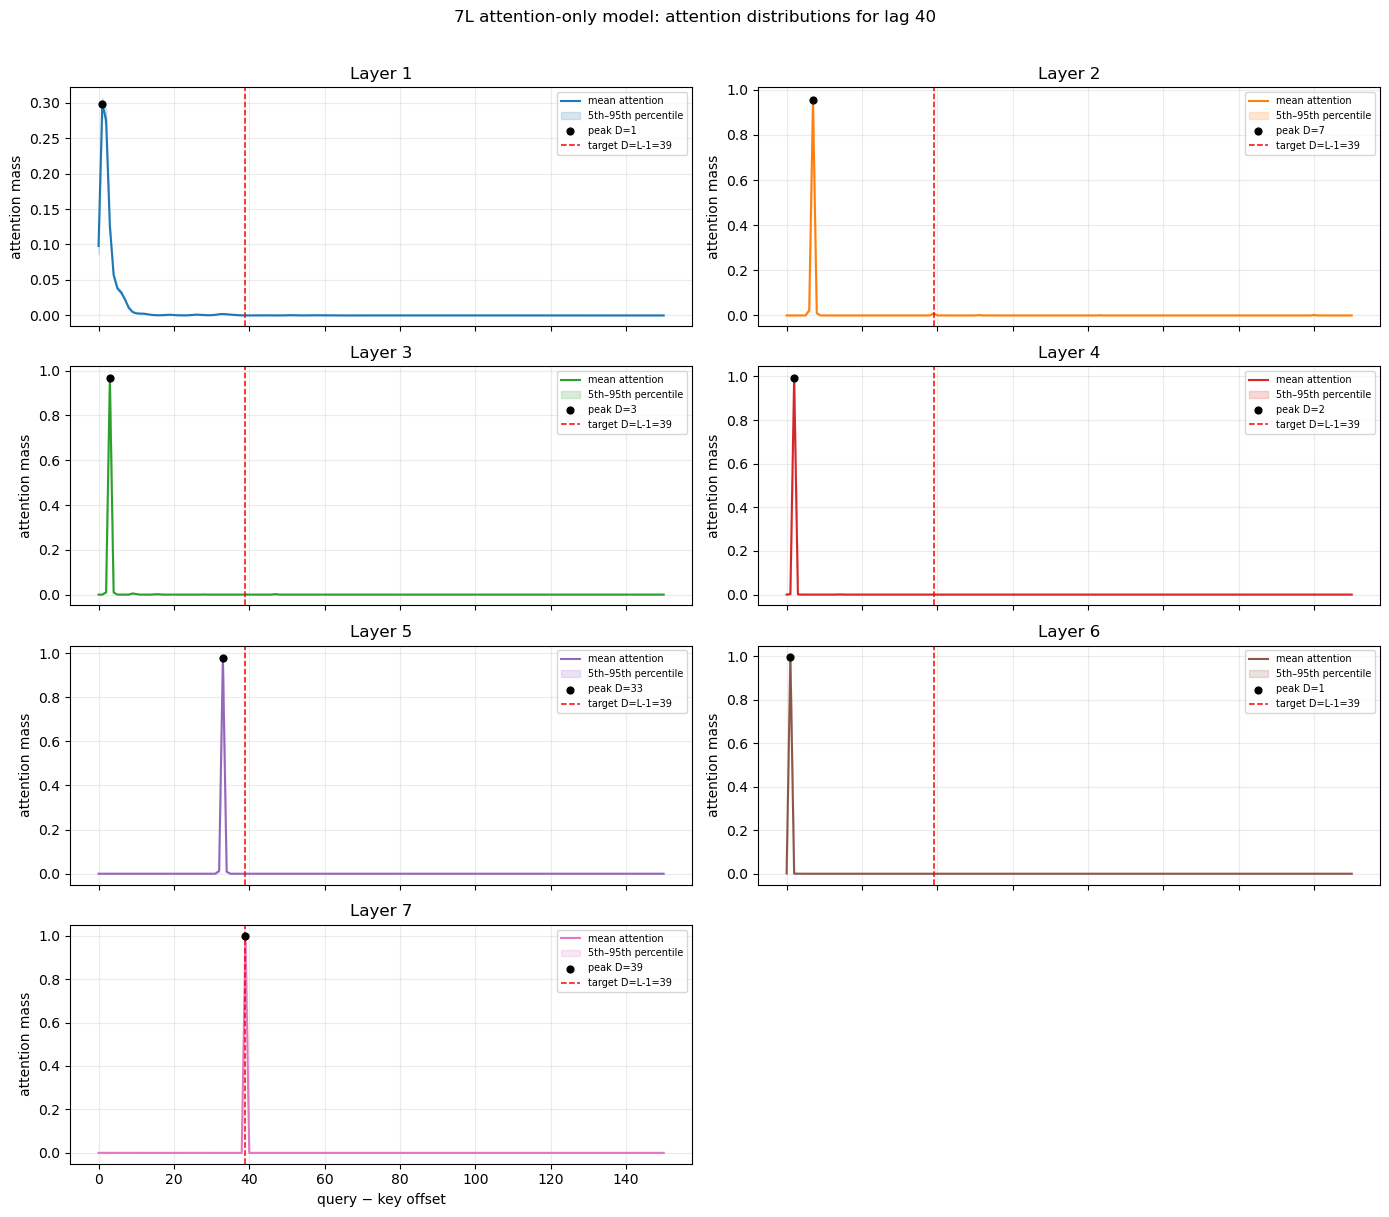

running lag 60...


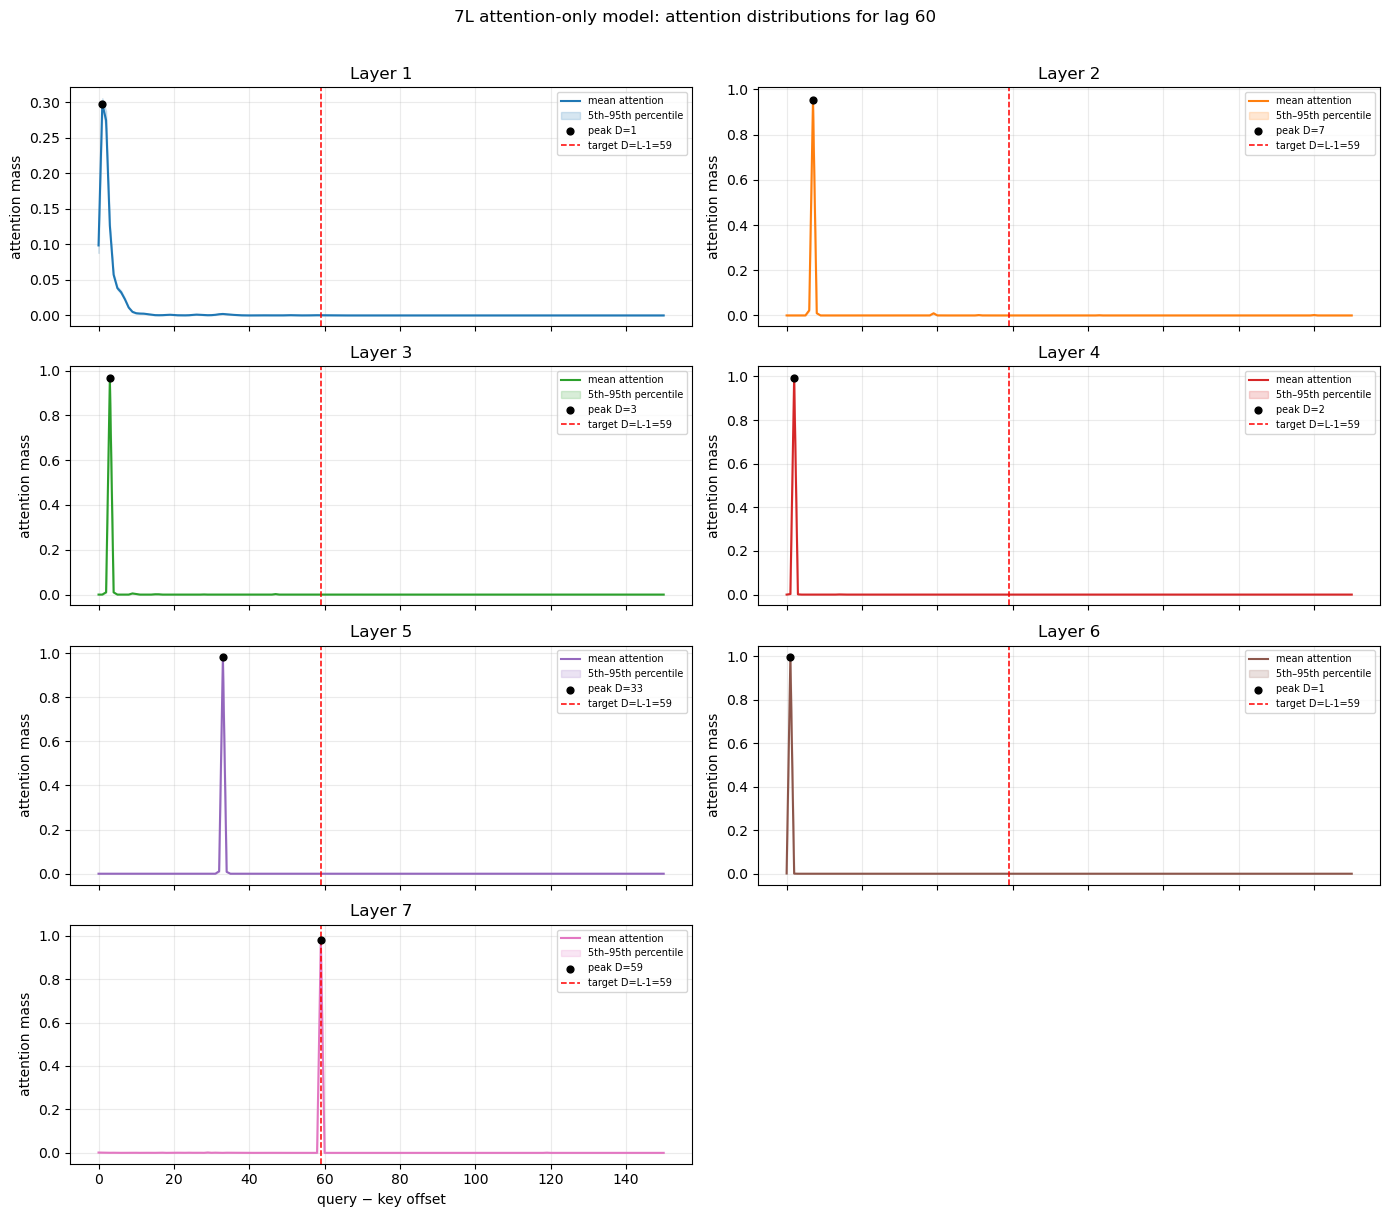

running lag 80...


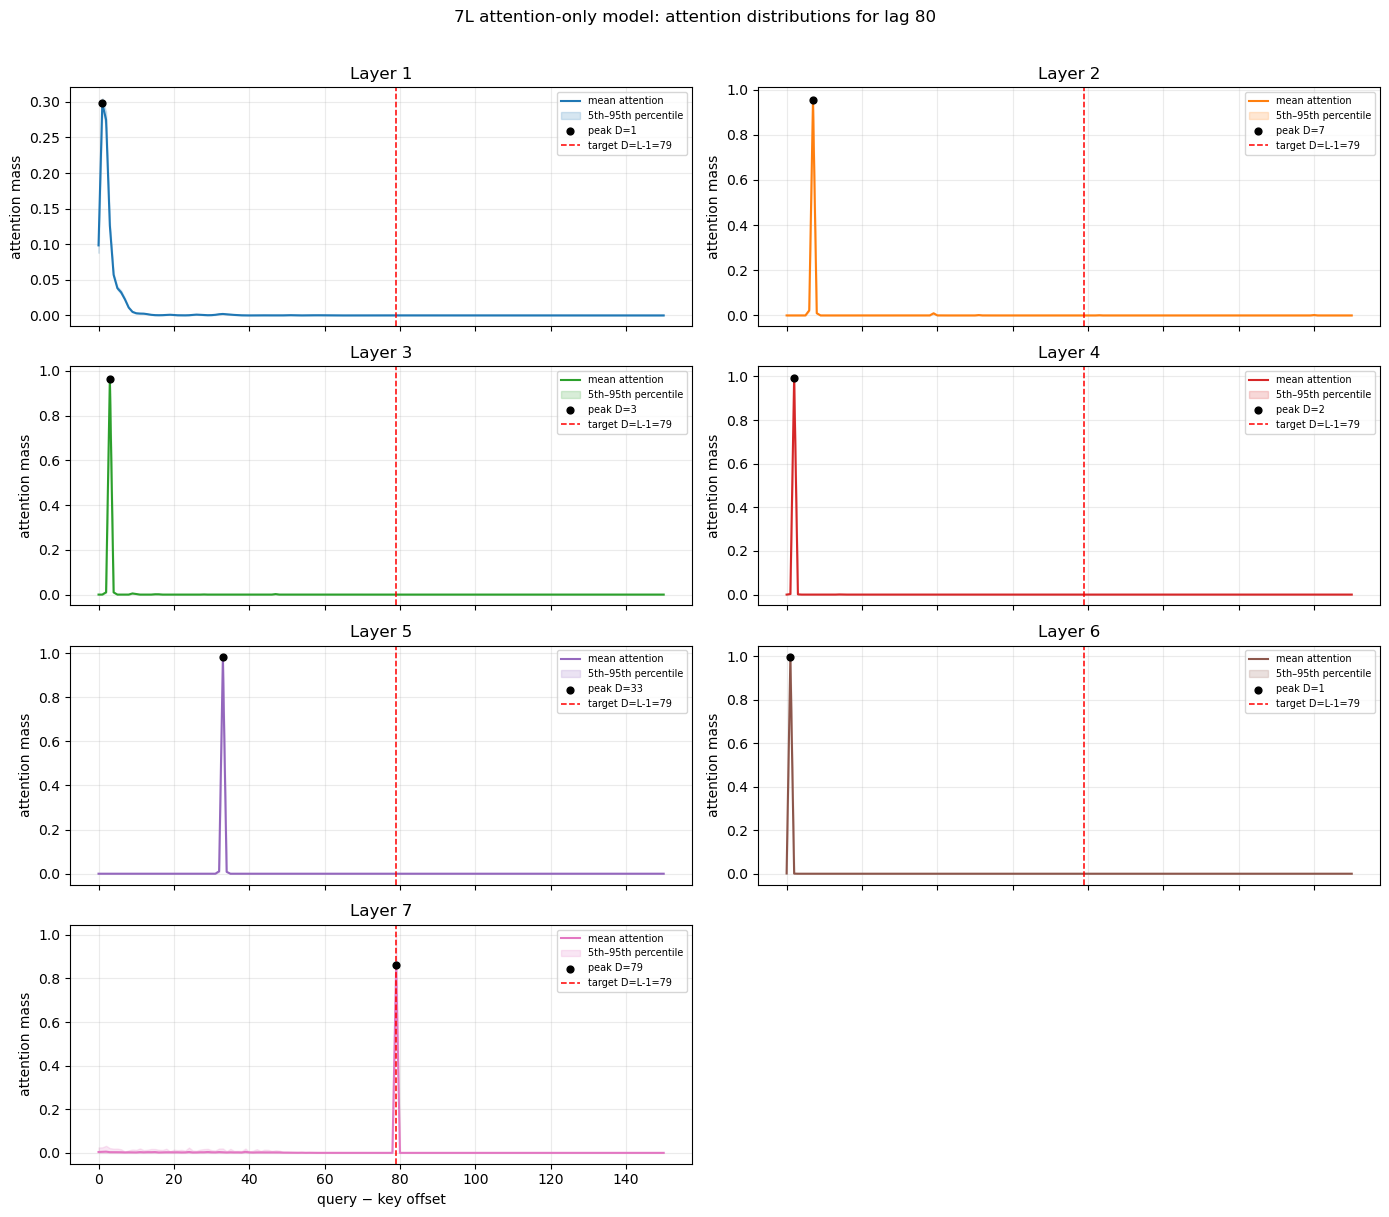


ATTENTION OFFSET-PROFILE SUMMARY
  lag | layer | target | mean peak |  mode |  mode % |   top offset mean ± SD | exact % |   ±1 % | mass@target
--------------------------------------------------------------------------------------------------------------------
   10 |     1 |      9 |         1 |     1 |   95.0% |      1.1 ±    0.2 |    0.0% |   0.0% |    0.005028
   10 |     2 |      9 |         7 |     7 |  100.0% |      7.0 ±    0.0 |    0.0% |   0.0% |    0.000000
   10 |     3 |      9 |         3 |     3 |  100.0% |      3.0 ±    0.0 |    0.0% |   0.0% |    0.004476
   10 |     4 |      9 |         2 |     2 |  100.0% |      2.0 ±    0.0 |    0.0% |   0.0% |    0.000001
   10 |     5 |      9 |        33 |    33 |  100.0% |     33.0 ±    0.0 |    0.0% |   0.0% |    0.000000
   10 |     6 |      9 |         1 |     1 |  100.0% |      1.0 ±    0.0 |    0.0% |   0.0% |    0.000000
   10 |     7 |      9 |         9 |     9 |  100.0% |      9.0 ±    0.0 |  100.0% | 100.0% |    0.978

In [39]:
# ============================================================
# ATTENTION DISTRIBUTIONS — 7L ATTENTION-ONLY MODEL
# Many sequences at each lag; normal (not logarithmic) scale.
# ============================================================
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

attention_model = model_attn_7L
attention_model.eval()
assert attention_model.n_layers == 7
assert attention_model.n_heads == 1
assert not attention_model.use_mlp

ATTN_LAGS = [10, 20, 40, 60, 80]
ATTN_N_SEQUENCES = 300
ATTN_T = 200
ATTN_RHO = 0.9
ATTN_MAX_OFFSET = 150
# Using the same late queries for every offset makes profile values comparable.
ATTN_QUERY_START = ATTN_MAX_OFFSET


def per_sequence_offset_profiles(A, max_offset, query_start):
    """
    A: (n_sequences, query_position, key_position).
    Returns (n_sequences, max_offset + 1), where entry [s,D] is
    mean_q A[s,q,q-D] over the fixed late-query range.
    """
    _, sequence_length, _ = A.shape
    queries = torch.arange(query_start, sequence_length, device=A.device)
    profiles = []
    for offset in range(max_offset + 1):
        valid_queries = queries[queries >= offset]
        profiles.append(A[:, valid_queries, valid_queries - offset].mean(dim=1))
    return torch.stack(profiles, dim=1)


attention_distribution_results = {}
attention_summary_rows = []

for lag_index, lag in enumerate(ATTN_LAGS):
    print(f"running lag {lag}...")
    sequences = np.stack([
        generate_autocorr(ATTN_T, ATTN_RHO, lag, seed=10_000 * lag + s)
        for s in range(ATTN_N_SEQUENCES)
    ])
    x_attention = torch.tensor(sequences, dtype=torch.float32, device=device)

    with torch.inference_mode():
        _, layer_attentions, _, _ = attention_model(x_attention)

    target_offset = lag - 1
    layer_profiles = []

    for layer_index, A in enumerate(layer_attentions):
        profiles = per_sequence_offset_profiles(
            A, ATTN_MAX_OFFSET, ATTN_QUERY_START
        ).detach().cpu().numpy()
        layer_profiles.append(profiles)

        mean_profile = profiles.mean(axis=0)
        # Exclude self-attention offset zero when identifying the retrieval peak.
        sequence_top_offsets = 1 + profiles[:, 1:].argmax(axis=1)
        mean_profile_peak = 1 + int(mean_profile[1:].argmax())
        counts = np.bincount(
            sequence_top_offsets, minlength=ATTN_MAX_OFFSET + 1
        )
        mode_offset = int(counts.argmax())

        attention_summary_rows.append({
            'lag': lag,
            'layer': layer_index + 1,
            'target': target_offset,
            'mean_profile_peak': mean_profile_peak,
            'mode': mode_offset,
            'mode_fraction': counts[mode_offset] / ATTN_N_SEQUENCES,
            'median_top_offset': float(np.median(sequence_top_offsets)),
            'mean_top_offset': float(sequence_top_offsets.mean()),
            'sd_top_offset': float(sequence_top_offsets.std(ddof=1)),
            'exact_fraction': float(np.mean(sequence_top_offsets == target_offset)),
            'within_one_fraction': float(
                np.mean(np.abs(sequence_top_offsets - target_offset) <= 1)
            ),
            'target_mass': float(profiles[:, target_offset].mean()),
        })

    attention_distribution_results[lag] = layer_profiles

    # One normal-scale figure per lag. Each layer gets its own y-scale so that
    # Layer 1's broader profile and Layers 2–7's sharp peaks are both visible.
    fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
    axes = axes.ravel()
    offsets = np.arange(ATTN_MAX_OFFSET + 1)

    for layer_index, profiles in enumerate(layer_profiles):
        ax = axes[layer_index]
        mean_profile = profiles.mean(axis=0)
        low, high = np.percentile(profiles, [5, 95], axis=0)
        peak_offset = 1 + int(mean_profile[1:].argmax())

        ax.plot(offsets, mean_profile, color=f'C{layer_index}', lw=1.5,
                label='mean attention')
        ax.fill_between(offsets, low, high, color=f'C{layer_index}',
                        alpha=0.18, label='5th–95th percentile')
        ax.scatter([peak_offset], [mean_profile[peak_offset]], color='black',
                   s=24, zorder=3, label=f'peak D={peak_offset}')
        ax.axvline(target_offset, color='red', ls='--', lw=1.1,
                   label=f'target D=L-1={target_offset}')
        ax.set_title(f'Layer {layer_index + 1}')
        ax.set_ylabel('attention mass')
        ax.grid(alpha=0.25)
        ax.legend(fontsize=7)

    axes[-1].axis('off')
    for ax in axes[-2:]:
        if ax.axison:
            ax.set_xlabel('query − key offset')
    fig.suptitle(
        f'7L attention-only model: attention distributions for lag {lag}',
        y=1.01,
    )
    fig.tight_layout()
    plt.show()


print("\nATTENTION OFFSET-PROFILE SUMMARY")
print(
    f"{'lag':>5} | {'layer':>5} | {'target':>6} | {'mean peak':>9} | "
    f"{'mode':>5} | {'mode %':>7} | {'top offset mean ± SD':>22} | "
    f"{'exact %':>7} | {'±1 %':>6} | {'mass@target':>11}"
)
print('-' * 116)
for row in attention_summary_rows:
    print(
        f"{row['lag']:5d} | {row['layer']:5d} | {row['target']:6d} | "
        f"{row['mean_profile_peak']:9d} | {row['mode']:5d} | "
        f"{100 * row['mode_fraction']:6.1f}% | "
        f"{row['mean_top_offset']:8.1f} ± {row['sd_top_offset']:6.1f} | "
        f"{100 * row['exact_fraction']:6.1f}% | "
        f"{100 * row['within_one_fraction']:5.1f}% | "
        f"{row['target_mass']:11.6f}"
    )


## Bilinear residual-pair probe and held-out boxplots

Start with a two-dimensional example. Suppose the residual at the later/query position is $(a,b)$ and the residual at the earlier/key position is $(c,d)$. We want the regression to examine every possible relationship between one coordinate of the first vector and one coordinate of the second vector.

The regression score therefore has the form

$$\text{score}=\text{bias}+w_{ac}(ac)+w_{ad}(ad)+w_{bc}(bc)+w_{bd}(bd).$$

Those four products are precisely the entries of the outer product:

$$\begin{pmatrix}a\\b\end{pmatrix}\begin{pmatrix}c&d\end{pmatrix}=\begin{pmatrix}ac&ad\\bc&bd\end{pmatrix}.$$

Logistic regression learns one weight for each entry. Put those learned weights into a matrix

$$J=\begin{pmatrix}w_{ac}&w_{ad}\\w_{bc}&w_{bd}\end{pmatrix}.$$

The long regression sum can then be written compactly as

$$\text{score}=\text{bias}+\begin{pmatrix}a&b\end{pmatrix}J\begin{pmatrix}c\\d\end{pmatrix}.$$

For the real model, each residual vector has 64 coordinates rather than two. The outer product therefore supplies $64\times64=4096$ coordinate-pair products, and $J$ is the learned $64\times64$ table of weights. In column-vector language, the same score is `bias + h_query.T @ J @ h_key`.

A larger score means that the residual pair looks more like a correct-offset pair. Logistic regression turns this continuous score into a binary answer only by placing a threshold at zero.

The experiment trains on lag-40 sequences: pairs separated by the correct attention offset 39 are positive examples, while pairs at nearby wrong offsets are negative examples. It evaluates on completely separate sequences. There is no SVD restriction and no whitening: the probe uses the complete residual vectors. Individual input features are rescaled only to make optimization numerically stable, and that scaling is removed when the code recovers $J$. Each dot in the boxplot is the mean score for one held-out sequence.

full residual bilinear feature count: 64 x 64 = 4096
held-out pair ROC-AUC: 0.9997
held-out pair balanced accuracy: 0.9958
max |logistic score - (b + h_i^T J h_j)|: 1.030e-06

Held-out sequence-level continuous scores (mean ± SD):
  incorrect offsets: -12.163 ± 2.629
  correct offset 39: +13.691 ± 4.799


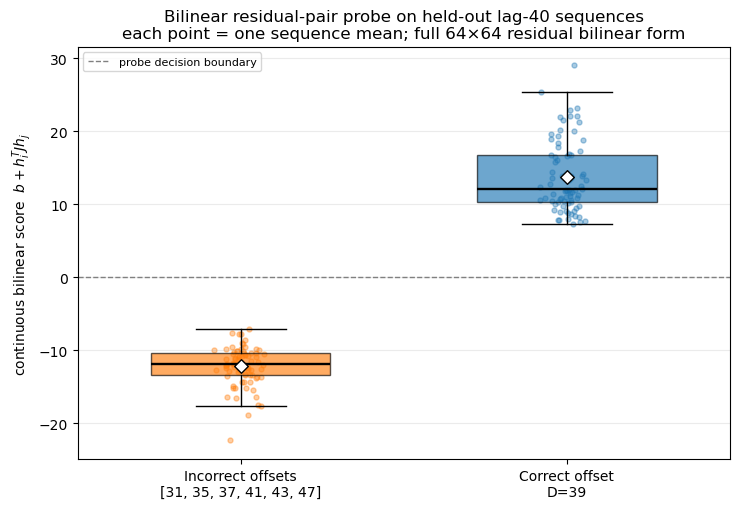

array([[-1.86551089e-03,  4.16053866e-03,  1.93195207e-03, ...,
        -1.29898924e-02, -1.98071026e-02, -1.44835203e-02],
       [-1.24017848e-02, -1.50069879e-02, -3.39340701e-03, ...,
         1.43175156e-03, -6.45454493e-03,  1.48752164e-02],
       [ 3.33218787e-03,  1.03469267e-02, -9.36674641e-03, ...,
        -1.68108611e-02,  3.63177715e-03, -3.37570283e-02],
       ...,
       [-2.48176381e-03,  2.07924599e-02, -7.95650326e-05, ...,
        -1.45134265e-02, -1.07621009e-02, -1.26966595e-02],
       [ 9.94891579e-03,  1.07045896e-03,  9.62779920e-03, ...,
         5.14975889e-03, -5.09434415e-03,  1.10374771e-02],
       [ 1.40582106e-02,  2.41343956e-03,  1.95152409e-02, ...,
        -2.57114299e-03, -1.16177047e-02,  5.85239236e-03]])

In [40]:
# ============================================================
# BILINEAR PROBE: correct-offset vs nearby-wrong residual pairs
# Model: 7-layer attention-only extended checkpoint already loaded above.
# Tensor code stores residuals as rows, but the displayed equation uses
# the column-vector convention h_i^T J h_j.
# ============================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

probe_model = model_attn_7L
probe_model.eval()

PROBE_LAG = 40
D_CORRECT = PROBE_LAG - 1
D_WRONG = [D_CORRECT + d for d in (-8, -4, -2, 2, 4, 8)]
PROBE_T = 200
PROBE_RHO = 0.9
PROBE_QUERY_START = 120
PROBE_QUERY_STRIDE = 4
PROBE_N_TRAIN = 80
PROBE_N_TEST = 80
PROBE_D_MODEL = probe_model.W_r.out_features
print(f"full residual bilinear feature count: "
      f"{PROBE_D_MODEL} x {PROBE_D_MODEL} = {PROBE_D_MODEL**2}")


@torch.no_grad()
def probe_final_layer_input(n_sequences, seed0):
    sequences = np.stack([
        generate_autocorr(PROBE_T, PROBE_RHO, PROBE_LAG, seed=seed0 + s)
        for s in range(n_sequences)
    ])
    x = torch.tensor(sequences, dtype=torch.float32, device=device)
    if probe_model.n_layers == 1:
        return probe_model.W_r(x.unsqueeze(-1))
    _, _, _, residuals_post_layer = probe_model(x)
    # Input to final layer L is the output of layer L-1.
    return residuals_post_layer[-2].detach()


query_positions = torch.arange(
    PROBE_QUERY_START, PROBE_T, PROBE_QUERY_STRIDE, device=device
)


def bilinear_features(H, offset, return_residual_pairs=False):
    """vec[h_i h_{i-D}^T] for every sequence/query."""
    h_query = H[:, query_positions, :]
    h_key = H[:, query_positions - offset, :]
    features = torch.einsum('bqd,bqe->bqde', h_query, h_key).reshape(
        -1, PROBE_D_MODEL * PROBE_D_MODEL
    )
    features_np = features.detach().cpu().numpy()
    if not return_residual_pairs:
        return features_np
    return (
        features_np,
        h_query.reshape(-1, h_query.shape[-1]).detach().cpu().numpy(),
        h_key.reshape(-1, h_key.shape[-1]).detach().cpu().numpy(),
    )


# ---------------- fit on one set of sequences ----------------
H_train = probe_final_layer_input(PROBE_N_TRAIN, seed0=0)
X_train_correct = bilinear_features(H_train, D_CORRECT)
X_train_wrong = np.concatenate([
    bilinear_features(H_train, D) for D in D_WRONG
], axis=0)
X_train = np.concatenate([X_train_correct, X_train_wrong], axis=0)
y_train = np.concatenate([
    np.ones(len(X_train_correct), dtype=np.int64),
    np.zeros(len(X_train_wrong), dtype=np.int64),
])

# This is coordinate-wise standardization, not whitening. We undo it below.
probe_scaler = StandardScaler().fit(X_train)
bilinear_probe = LogisticRegression(
    max_iter=3000, C=1.0, class_weight='balanced', solver='liblinear',
    random_state=0
).fit(probe_scaler.transform(X_train), y_train)


# ---------------- evaluate on disjoint sequences ----------------
H_test = probe_final_layer_input(PROBE_N_TEST, seed0=100_000)
X_test_correct, hq_correct, hk_correct = bilinear_features(
    H_test, D_CORRECT, return_residual_pairs=True
)

wrong_blocks = [
    bilinear_features(H_test, D, return_residual_pairs=True) for D in D_WRONG
]
X_test_wrong = np.concatenate([block[0] for block in wrong_blocks], axis=0)
hq_wrong = np.concatenate([block[1] for block in wrong_blocks], axis=0)
hk_wrong = np.concatenate([block[2] for block in wrong_blocks], axis=0)

X_test = np.concatenate([X_test_correct, X_test_wrong], axis=0)
y_test = np.concatenate([
    np.ones(len(X_test_correct), dtype=np.int64),
    np.zeros(len(X_test_wrong), dtype=np.int64),
])
probe_scores = bilinear_probe.decision_function(probe_scaler.transform(X_test))
probe_predictions = (probe_scores > 0).astype(np.int64)


# ---------------- recover the literal residual-space bilinear form ----------------
# z = b_scaled + w_scaled @ ((x - mean) / scale)
#   = b_raw    + w_raw @ x
w_scaled = bilinear_probe.coef_.ravel()
w_raw = w_scaled / probe_scaler.scale_
b_raw = float(
    bilinear_probe.intercept_[0]
    - np.dot(w_scaled, probe_scaler.mean_ / probe_scaler.scale_)
)
J_probe = w_raw.reshape(PROBE_D_MODEL, PROBE_D_MODEL)

hq_all = np.concatenate([hq_correct, hq_wrong], axis=0)
hk_all = np.concatenate([hk_correct, hk_wrong], axis=0)
direct_J_scores = b_raw + np.einsum('nd,df,nf->n', hq_all, J_probe, hk_all)
max_equivalence_error = float(np.max(np.abs(direct_J_scores - probe_scores)))

print(f"held-out pair ROC-AUC: {roc_auc_score(y_test, probe_scores):.4f}")
print(f"held-out pair balanced accuracy: "
      f"{balanced_accuracy_score(y_test, probe_predictions):.4f}")
print(f"max |logistic score - (b + h_i^T J h_j)|: "
      f"{max_equivalence_error:.3e}")


# One value per held-out sequence: average over its fixed query positions.
n_queries = len(query_positions)
correct_pair_scores = direct_J_scores[:len(X_test_correct)]
wrong_pair_scores = direct_J_scores[len(X_test_correct):]
correct_sequence_scores = correct_pair_scores.reshape(
    PROBE_N_TEST, n_queries
).mean(axis=1)
wrong_sequence_scores = wrong_pair_scores.reshape(
    len(D_WRONG), PROBE_N_TEST, n_queries
).mean(axis=(0, 2))

print("\nHeld-out sequence-level continuous scores (mean ± SD):")
print(f"  incorrect offsets: {wrong_sequence_scores.mean():+.3f} "
      f"± {wrong_sequence_scores.std(ddof=1):.3f}")
print(f"  correct offset {D_CORRECT}: {correct_sequence_scores.mean():+.3f} "
      f"± {correct_sequence_scores.std(ddof=1):.3f}")


# ---------------- requested side-by-side boxplots ----------------
fig, ax = plt.subplots(figsize=(7.5, 5.2))
box = ax.boxplot(
    [wrong_sequence_scores, correct_sequence_scores],
    tick_labels=[f'Incorrect offsets\n{D_WRONG}', f'Correct offset\nD={D_CORRECT}'],
    patch_artist=True,
    showfliers=False,
    widths=0.55,
    medianprops=dict(color='black', linewidth=1.7),
)
box['boxes'][0].set_facecolor('tab:orange')
box['boxes'][1].set_facecolor('tab:blue')
for patch in box['boxes']:
    patch.set_alpha(0.65)

rng = np.random.default_rng(0)
for x_position, values, color in [
    (1, wrong_sequence_scores, 'tab:orange'),
    (2, correct_sequence_scores, 'tab:blue'),
]:
    jitter = rng.normal(0, 0.035, size=len(values))
    ax.scatter(x_position + jitter, values, s=13, alpha=0.38, color=color)
    ax.scatter(x_position, values.mean(), marker='D', s=48,
               color='white', edgecolor='black', zorder=4)

ax.axhline(0, color='gray', linestyle='--', linewidth=1,
           label='probe decision boundary')
ax.set_ylabel(r'continuous bilinear score  $b+h_i^T J h_j$')
ax.set_title(
    f'Bilinear residual-pair probe on held-out lag-{PROBE_LAG} sequences\n'
    f'each point = one sequence mean; full {PROBE_D_MODEL}×{PROBE_D_MODEL} residual bilinear form'
)
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='best', fontsize=8)
fig.tight_layout()
plt.show()

J_probe  # 64 x 64 learned residual-space relationship for later analyses
